# Module 06c: GSEA Prerank Analysis

## Biological Question
Are there coordinated, directional pathway shifts between SnC and Non-SnC cells that may be missed by significance-based ORA?

## Rationale
GSEA uses all tested genes (ranked) rather than only significant DEGs, detecting subtle but coordinated pathway-level changes that ORA may miss.

## Method
- Rank all tested genes by: `-log10(pval) × sign(logFC)`
- Run GSEA prerank (GSEApy) against pathway databases

## Databases
Reactome_2022, KEGG_2021_Human, GO_Biological_Process_2023

## Cell Types
Astrocyte, OPC

In [1]:
# ============================================================
# MODULE 06c: GSEA PRERANK ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gseapy as gp
from pathlib import Path

# ------------------------------------------------------------
# Dataset Selection
# ------------------------------------------------------------
DATASET = 'psychad_aging'

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
BASE_DIR = Path('/fs/scratch/PAS2598/senescence_analysis')

# Input from Module 05
INPUT_DIR = BASE_DIR / 'results' / '05_deg' / DATASET

# Output directories
OUTPUT_DIR = BASE_DIR / 'data' / '06_pathway_enrichment' / DATASET / 'gsea_prerank'
RESULTS_DIR = BASE_DIR / 'results' / '06_pathway_enrichment' / DATASET / 'gsea_prerank'
FIGURES_DIR = BASE_DIR / 'figures' / '06_pathway_enrichment' / DATASET / 'gsea_prerank'

for d in [OUTPUT_DIR, RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Column Mapping (from Module 05 DEG output)
# ------------------------------------------------------------
COL_GENE = 'gene'
COL_LFC = 'avg_log2FC'
COL_PVAL = 'p_val'
COL_FDR = 'p_val_adj'

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
FDR_THRESHOLD = 0.05
RANKING_METHOD = 'signed_pval'  # -log10(pval) × sign(logFC)

# Focus on Microglia first
CELL_TYPE = 'Astrocyte'

# Start with one database
DATABASE = 'Reactome_2022'

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print("=" * 60)
print("MODULE 06c: GSEA PRERANK")
print("=" * 60)
print(f"\nDataset: {DATASET}")
print(f"Cell type: {CELL_TYPE}")
print(f"Database: {DATABASE}")
print(f"Ranking method: {RANKING_METHOD}")
print(f"\nPaths:")
print(f"  Input:   {INPUT_DIR}/")
print(f"  Output:  {OUTPUT_DIR}/")
print(f"  Results: {RESULTS_DIR}/")
print(f"  Figures: {FIGURES_DIR}/")

MODULE 06c: GSEA PRERANK

Dataset: psychad_aging
Cell type: Astrocyte
Database: Reactome_2022
Ranking method: signed_pval

Paths:
  Input:   /fs/scratch/PAS2598/senescence_analysis/results/05_deg/psychad_aging/
  Output:  /fs/scratch/PAS2598/senescence_analysis/data/06_pathway_enrichment/psychad_aging/gsea_prerank/
  Results: /fs/scratch/PAS2598/senescence_analysis/results/06_pathway_enrichment/psychad_aging/gsea_prerank/
  Figures: /fs/scratch/PAS2598/senescence_analysis/figures/06_pathway_enrichment/psychad_aging/gsea_prerank/


In [2]:
# ============================================================
# Load DEG Data
# ============================================================

# DEG file path
deg_file = INPUT_DIR / CELL_TYPE.lower() / f"{DATASET}_{CELL_TYPE.lower()}_SnCvsNonSnC_all.csv"

print(f"Loading: {deg_file.name}")

# Load data
df = pd.read_csv(deg_file)

print(f"\n✓ Loaded {len(df):,} genes")
print(f"\nColumns: {list(df.columns)}")
print(f"\nHead:")
print(df.head())

Loading: psychad_aging_astrocyte_SnCvsNonSnC_all.csv

✓ Loaded 14,086 genes

Columns: ['gene', 'avg_log2FC', 'p_val', 'p_val_adj', 'pct.1', 'pct.2', 'significant', 'direction']

Head:
     gene  avg_log2FC     p_val  p_val_adj     pct.1     pct.2  significant  \
0  TSPAN6    0.336668  0.111243   0.359479  0.769231  0.984615        False   
1    DPM1    0.008543  0.906283   0.963901  0.907692  1.000000        False   
2   SCYL3   -0.036728  0.643237   0.835544  0.892308  1.000000        False   
3   FIRRM   -0.117666  0.270765   0.561179  0.861538  1.000000        False   
4   FUCA2    0.199245  0.106481   0.350933  0.753846  0.984615        False   

  direction  
0        NS  
1        NS  
2        NS  
3        NS  
4        NS  


In [3]:
# ============================================================
# Create Ranking Metric
# ============================================================

def create_ranking(df: pd.DataFrame, method: str = 'signed_pval') -> pd.Series:
    """
    Create gene ranking for GSEA prerank.
    
    Methods:
    - 'signed_pval': -log10(pval) × sign(logFC) — rewards significance + direction
    - 'logFC': Simple log fold change
    """
    if method == 'signed_pval':
        # Clip p-values to avoid inf
        pval_clipped = df[COL_PVAL].clip(lower=1e-300)
        score = -np.log10(pval_clipped) * np.sign(df[COL_LFC])
        ranking = pd.Series(score.values, index=df[COL_GENE])
    elif method == 'logFC':
        ranking = df.set_index(COL_GENE)[COL_LFC]
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Remove NaN/inf and sort
    ranking = ranking.replace([np.inf, -np.inf], np.nan).dropna()
    ranking = ranking.sort_values(ascending=False)
    
    return ranking

# Create ranking
ranking = create_ranking(df, method=RANKING_METHOD)

# Display
N_DISPLAY = 10

print(f"Ranking method: {RANKING_METHOD}")
print(f"Genes ranked: {len(ranking):,}")
print(f"\nTop {N_DISPLAY} (upregulated in SnC):")
print(ranking.head(N_DISPLAY))
print(f"\nBottom {N_DISPLAY} (downregulated in SnC):")
print(ranking.tail(N_DISPLAY))

Ranking method: signed_pval
Genes ranked: 14,086

Top 10 (upregulated in SnC):
gene
PARM1              10.412893
MAP7D2              8.108026
SLC6A17             7.578974
RALYL               7.452127
ENSG00000228358     7.335504
CACNG3              7.280069
GCSHP2              7.094715
PIANP               7.066792
ADAM11              7.020279
SYNGR3              7.010826
dtype: float64

Bottom 10 (downregulated in SnC):
gene
GPC5              -5.637821
PITPNC1           -5.694157
MAPK10            -5.818288
MAGI2             -6.043746
ZBTB20            -6.062786
LRP1B             -6.069216
CADM2             -6.351538
MEIS2             -6.373509
LINC00472         -6.946688
ENSG00000258028   -7.244408
dtype: float64


In [4]:
# ============================================================
# Run GSEA Prerank
# ============================================================

print(f"Running GSEA prerank: {DATABASE}")
print(f"Genes: {len(ranking):,}")

# Output directory for this run
outdir = OUTPUT_DIR / CELL_TYPE.lower() / DATABASE

pre_res = gp.prerank(
    rnk=ranking,
    gene_sets=DATABASE,
    outdir=str(outdir),
    min_size=15,
    max_size=500,
    permutation_num=1000,
    threads=4,
    seed=42,
    verbose=True
)

print(f"\n✓ Complete")
print(f"Output: {outdir}")

2026-02-18 17:30:58,732 [INFO] Parsing data files for GSEA.............................
2026-02-18 17:30:58,749 [INFO] Enrichr library gene sets already downloaded in: /users/PAS2598/ggaitos/.cache/gseapy, use local file
2026-02-18 17:30:58,787 [INFO] 0882 gene_sets have been filtered out when max_size=500 and min_size=15
2026-02-18 17:30:58,788 [INFO] 0936 gene_sets used for further statistical testing.....
2026-02-18 17:30:58,788 [INFO] Start to run GSEA...Might take a while..................


Running GSEA prerank: Reactome_2022
Genes: 14,086


2026-02-18 17:31:29,531 [INFO] Congratulations. GSEApy runs successfully................




✓ Complete
Output: /fs/scratch/PAS2598/senescence_analysis/data/06_pathway_enrichment/psychad_aging/gsea_prerank/astrocyte/Reactome_2022


In [5]:
# ============================================================
# Examine Results
# ============================================================

# Results dataframe
res = pre_res.res2d

print(f"Results: {len(res)} pathways tested")
print(f"\nColumns: {list(res.columns)}")

# Significant pathways
n_sig = (res['FDR q-val'] < FDR_THRESHOLD).sum()
n_up = ((res['FDR q-val'] < FDR_THRESHOLD) & (res['NES'] > 0)).sum()
n_down = ((res['FDR q-val'] < FDR_THRESHOLD) & (res['NES'] < 0)).sum()

print(f"\nSignificant (FDR < {FDR_THRESHOLD}): {n_sig}")
print(f"  Enriched in SnC (NES > 0): {n_up}")
print(f"  Enriched in Non-SnC (NES < 0): {n_down}")

print(f"\nTop results:")
print(res.head(10))

Results: 936 pathways tested

Columns: ['Name', 'Term', 'ES', 'NES', 'NOM p-val', 'FDR q-val', 'FWER p-val', 'Tag %', 'Gene %', 'Lead_genes']

Significant (FDR < 0.05): 43
  Enriched in SnC (NES > 0): 42
  Enriched in Non-SnC (NES < 0): 1

Top results:
      Name                                               Term        ES  \
0  prerank     Eukaryotic Translation Elongation R-HSA-156842  0.640508   
1  prerank              Peptide Chain Elongation R-HSA-156902  0.625206   
2  prerank                        rRNA Processing R-HSA-72312  0.556362   
3  prerank  Major Pathway Of rRNA Processing In Nucleolus ...  0.557299   
4  prerank  rRNA Processing In Nucleus And Cytosol R-HSA-8...  0.554412   
5  prerank  SRP-dependent Cotranslational Protein Targetin...  0.587123   
6  prerank     Eukaryotic Translation Termination R-HSA-72764  0.610832   
7  prerank  Cooperation Of Prefoldin And TriC/CCT In Actin...    0.7448   
8  prerank  Formation Of A Pool Of Free 40S Subunits R-HSA...  0.591624 

In [6]:
# ============================================================
# Top Pathways by Direction
# ============================================================

# Filter significant
sig = res[res['FDR q-val'] < FDR_THRESHOLD].copy()

# Split by direction
sig_up = sig[sig['NES'] > 0].sort_values('NES', ascending=False)
sig_down = sig[sig['NES'] < 0].sort_values('NES', ascending=True)

# Display columns
display_cols = ['Term', 'NES', 'FDR q-val', 'Lead_genes']

print(f"Enriched in SnC (NES > 0): {len(sig_up)} pathways")
print("=" * 60)
print(sig_up[display_cols].head(10).to_string(index=False))

print(f"\n\nEnriched in Non-SnC (NES < 0): {len(sig_down)} pathways")
print("=" * 60)
print(sig_down[display_cols].head(10).to_string(index=False))

Enriched in SnC (NES > 0): 42 pathways
                                                                           Term       NES FDR q-val                                                                                                                                                                                                                                                                                                                                                                                    Lead_genes
                                 Eukaryotic Translation Elongation R-HSA-156842  2.167529       0.0                                                                                                                                                                   RPL8;EEF1A2;EEF2;RPLP2;RPL35;RPL32;RPL38;UBA52;RPL4;RPS21;RPS6;RPL13A;RSL24D1;RPS11;RPL14;RPS20;RPL36;RPL27;RPL23;RPL37;EEF1B2;RPS15;RPL3;RPL37A;RPLP1;RPS4Y1;FAU;RPS8;RPS27;RPL5;EEF1D;RPL30;RPS12;RPL31;RPL19;RPL12;RPS

In [7]:
# ============================================================
# Save Results
# ============================================================

# Add metadata
res_out = res.copy()
res_out['Cell_Type'] = CELL_TYPE
res_out['Database'] = DATABASE
res_out['Dataset'] = DATASET

# Save full results
outfile = RESULTS_DIR / f"{DATASET}_{CELL_TYPE.lower()}_{DATABASE}_gsea_prerank.csv"
res_out.to_csv(outfile, index=False)

print(f"✓ Saved: {outfile.name}")
print(f"  Total pathways: {len(res_out)}")
print(f"  Significant (FDR < {FDR_THRESHOLD}): {n_sig}")

✓ Saved: psychad_aging_astrocyte_Reactome_2022_gsea_prerank.csv
  Total pathways: 936
  Significant (FDR < 0.05): 43


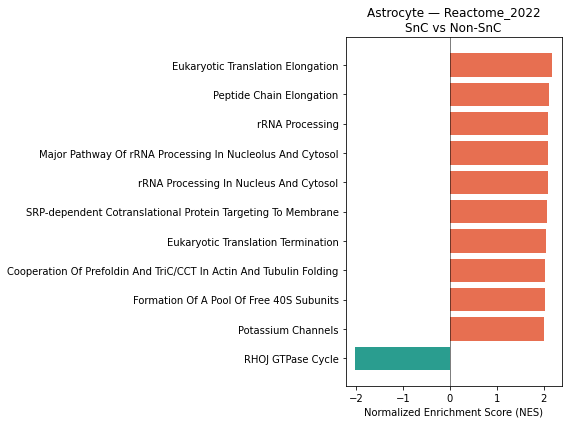


✓ Saved figure


In [8]:
# ============================================================
# Visualize: NES Bar Plot
# ============================================================

# Visualization
N_TOP = 10
N_DISPLAY = 10

# Colors
COLORS = {
    'up': '#E76F51',    # Burnt sienna
    'down': '#2A9D8F',  # Teal
}

top_up = sig_up.head(N_TOP).copy()
top_down = sig_down.head(N_TOP).copy()

# Combine and sort by NES
plot_df = pd.concat([top_up, top_down]).sort_values('NES', ascending=True)

# Clean pathway names (remove R-HSA-* suffix)
plot_df['Term_clean'] = plot_df['Term'].str.replace(r'\s*R-HSA-\d+$', '', regex=True)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

colors = [COLORS['up'] if x > 0 else COLORS['down'] for x in plot_df['NES']]

ax.barh(plot_df['Term_clean'], plot_df['NES'], color=colors)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Normalized Enrichment Score (NES)')
ax.set_title(f'{CELL_TYPE} — {DATABASE}\nSnC vs Non-SnC')

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{DATASET}_{CELL_TYPE.lower()}_{DATABASE}_nes_barplot.svg")
plt.show()

print(f"\n✓ Saved figure")

In [9]:
# ============================================================
# GSEA Enrichment Plot (Classic)
# ============================================================

# Check what's in the output directory
outdir = OUTPUT_DIR / CELL_TYPE.lower() / DATABASE
print(f"Output directory: {outdir}")
print(f"\nFiles generated:")
for f in sorted(outdir.glob('*'))[:20]:
    print(f"  {f.name}")

Output directory: /fs/scratch/PAS2598/senescence_analysis/data/06_pathway_enrichment/psychad_aging/gsea_prerank/astrocyte/Reactome_2022

Files generated:
  gene_sets.gmt
  gseapy.gene_set.prerank.report.csv
  prerank
  prerank_data.rnk


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


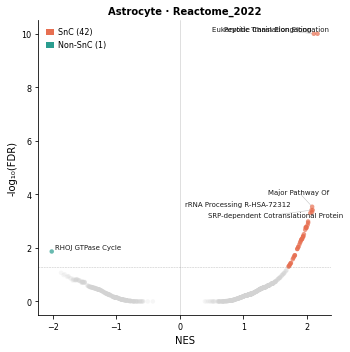

✓ Saved volcano plot


In [10]:
# ============================================================
# Visualize: Volcano Plot (NES vs -log10 FDR)
# ============================================================

from adjustText import adjust_text

# Prepare data
plot_df = res.copy()

# Ensure numeric dtypes
plot_df['NES'] = pd.to_numeric(plot_df['NES'], errors='coerce')
plot_df['FDR q-val'] = pd.to_numeric(plot_df['FDR q-val'], errors='coerce')

# Calculate -log10(FDR)
plot_df['neg_log10_fdr'] = -np.log10(plot_df['FDR q-val'].clip(lower=1e-10))

# Classify pathways
def classify_pathway(row):
    if row['FDR q-val'] >= FDR_THRESHOLD:
        return 'NS'
    elif row['NES'] > 0:
        return 'Up'
    else:
        return 'Down'

plot_df['Category'] = plot_df.apply(classify_pathway, axis=1)

# Colors
color_map = {
    'Up': COLORS['up'],
    'Down': COLORS['down'],
    'NS': '#D3D3D3'
}

# Plot
fig, ax = plt.subplots(figsize=(5, 5))

for cat in ['NS', 'Down', 'Up']:
    subset = plot_df[plot_df['Category'] == cat]
    ax.scatter(
        subset['NES'],
        subset['neg_log10_fdr'],
        c=color_map[cat],
        alpha=0.7 if cat != 'NS' else 0.2,
        s=20,
        edgecolors='none'
    )

# Reference lines
fdr_line = -np.log10(FDR_THRESHOLD)
ax.axhline(fdr_line, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

# Label top pathways (non-overlapping)
n_label = 5
top_up = plot_df[plot_df['Category'] == 'Up'].nlargest(n_label, 'neg_log10_fdr')
top_down = plot_df[plot_df['Category'] == 'Down'].nlargest(n_label, 'neg_log10_fdr')
to_label = pd.concat([top_up, top_down])

texts = []
for _, row in to_label.iterrows():
    # Clean pathway name (first 2-3 words)
    words = row['Term'].split()[0:3]
    label = ' '.join(words)
    
    texts.append(ax.text(
        row['NES'], 
        row['neg_log10_fdr'], 
        label,
        fontsize=7,
        alpha=0.9
    ))

# Adjust text positions to avoid overlap
adjust_text(
    texts, 
    ax=ax,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.5),
    expand_points=(1.5, 1.5),
    force_points=(0.5, 0.5)
)

# Styling
ax.set_xlabel('NES', fontsize=10)
ax.set_ylabel('-log₁₀(FDR)', fontsize=10)
ax.set_title(f'{CELL_TYPE} · {DATABASE}', fontsize=10, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=8)

# Legend (top left)
from matplotlib.patches import Patch
n_up = (plot_df['Category'] == 'Up').sum()
n_down = (plot_df['Category'] == 'Down').sum()

legend_elements = [
    Patch(facecolor=COLORS['up'], label=f'SnC ({n_up})'),
    Patch(facecolor=COLORS['down'], label=f'Non-SnC ({n_down})')
]
ax.legend(
    handles=legend_elements, 
    loc='upper left', 
    frameon=False, 
    fontsize=8,
    handlelength=1,
    handletextpad=0.5
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{DATASET}_{CELL_TYPE.lower()}_{DATABASE}_volcano.svg", dpi=300)
plt.savefig(FIGURES_DIR / f"{DATASET}_{CELL_TYPE.lower()}_{DATABASE}_volcano.svg")
plt.show()

print(f"✓ Saved volcano plot")

In [11]:
# ============================================================
# Scale to All Databases
# ============================================================

DATABASES = ['Reactome_2022', 'KEGG_2021_Human', 'GO_Biological_Process_2023']

# Store results
all_results = {}

for db in DATABASES:
    print(f"\n{'='*60}")
    print(f"Running: {db}")
    print('='*60)
    
    # Output directory
    outdir = OUTPUT_DIR / CELL_TYPE.lower() / db
    
    # Run GSEA prerank
    pre_res = gp.prerank(
        rnk=ranking,
        gene_sets=db,
        outdir=str(outdir),
        min_size=15,
        max_size=500,
        permutation_num=1000,
        threads=4,
        seed=42,
        verbose=False
    )
    
    # Get results
    res = pre_res.res2d.copy()
    res['NES'] = pd.to_numeric(res['NES'], errors='coerce')
    res['FDR q-val'] = pd.to_numeric(res['FDR q-val'], errors='coerce')
    
    # Add metadata
    res['Database'] = db
    res['Cell_Type'] = CELL_TYPE
    res['Dataset'] = DATASET
    
    all_results[db] = res
    
    # Summary
    n_sig = (res['FDR q-val'] < FDR_THRESHOLD).sum()
    n_up = ((res['FDR q-val'] < FDR_THRESHOLD) & (res['NES'] > 0)).sum()
    n_down = ((res['FDR q-val'] < FDR_THRESHOLD) & (res['NES'] < 0)).sum()
    
    print(f"✓ Tested: {len(res)} pathways")
    print(f"  Significant: {n_sig} (SnC: {n_up}, Non-SnC: {n_down})")

# Combine all results
combined = pd.concat(all_results.values(), ignore_index=True)

# Save combined
outfile = RESULTS_DIR / f"{DATASET}_{CELL_TYPE.lower()}_gsea_prerank_all.csv"
combined.to_csv(outfile, index=False)

print(f"\n{'='*60}")
print(f"✓ Saved combined results: {outfile.name}")
print(f"  Total pathways: {len(combined)}")


Running: Reactome_2022
✓ Tested: 936 pathways
  Significant: 43 (SnC: 42, Non-SnC: 1)

Running: KEGG_2021_Human
✓ Tested: 271 pathways
  Significant: 4 (SnC: 4, Non-SnC: 0)

Running: GO_Biological_Process_2023
✓ Tested: 1813 pathways
  Significant: 53 (SnC: 52, Non-SnC: 1)

✓ Saved combined results: psychad_aging_astrocyte_gsea_prerank_all.csv
  Total pathways: 3020


In [12]:
# ============================================================
# Export All Significant Pathways to CSV
# ============================================================

print(f"{'='*60}")
print(f"EXPORTING SIGNIFICANT PATHWAYS")
print(f"{'='*60}")

# Collect significant pathways from all databases
sig_pathways_list = []

for db, res in all_results.items():
    # Filter significant
    res_copy = res.copy()
    res_copy['NES'] = pd.to_numeric(res_copy['NES'], errors='coerce')
    res_copy['FDR q-val'] = pd.to_numeric(res_copy['FDR q-val'], errors='coerce')
    
    sig = res_copy[res_copy['FDR q-val'] < FDR_THRESHOLD].copy()
    
    if len(sig) > 0:
        # Add database column
        sig['Database'] = db
        
        # Add direction column
        sig['Direction'] = sig['NES'].apply(lambda x: 'SnC' if x > 0 else 'Non-SnC')
        
        # Clean pathway name (remove R-HSA codes and GO codes)
        def clean_pathway(name):
            import re
            name = re.sub(r'\s*R-HSA-\d+$', '', name)
            name = re.sub(r'\s*\(GO:\d+\)$', '', name)
            return name
        
        sig['Pathway'] = sig['Term'].apply(clean_pathway)
        
        # Select and reorder columns
        sig_clean = sig[['Database', 'Direction', 'Pathway', 'Term', 'NES', 'ES', 
                         'FDR q-val', 'FWER p-val', 'Lead_genes']].copy()
        
        sig_pathways_list.append(sig_clean)
        print(f"{db}: {len(sig)} significant pathways")

# Combine all
if sig_pathways_list:
    all_sig_pathways = pd.concat(sig_pathways_list, ignore_index=True)
    
    # Sort by Database, then Direction, then NES
    all_sig_pathways = all_sig_pathways.sort_values(
        by=['Database', 'Direction', 'NES'],
        ascending=[True, True, False]
    )
    
    # Convert numeric columns to numeric dtype
    numeric_cols = ['NES', 'ES', 'FDR q-val', 'FWER p-val']
    for col in numeric_cols:
        all_sig_pathways[col] = pd.to_numeric(all_sig_pathways[col], errors='coerce')
    
    # Round numeric columns
    all_sig_pathways['NES'] = all_sig_pathways['NES'].round(4)
    all_sig_pathways['ES'] = all_sig_pathways['ES'].round(4)
    all_sig_pathways['FDR q-val'] = all_sig_pathways['FDR q-val'].round(6)
    #all_sig_pathways['FDR p-val'] = all_sig_pathways['FDR p-val'].round(6)
    all_sig_pathways['FWER p-val'] = all_sig_pathways['FWER p-val'].round(6)
    
    # Save to CSV
    sig_file = RESULTS_DIR / f"{DATASET}_{CELL_TYPE.lower()}_gsea_significant_pathways.csv"
    all_sig_pathways.to_csv(sig_file, index=False)
    
    print(f"\n{'='*60}")
    print(f"TOTAL: {len(all_sig_pathways)} significant pathways")
    print(f"  SnC: {(all_sig_pathways['Direction'] == 'SnC').sum()}")
    print(f"  Non-SnC: {(all_sig_pathways['Direction'] == 'Non-SnC').sum()}")
    print(f"\n✓ Saved: {sig_file.name}")
    
    # Display preview
    print(f"\nPreview:")
    print(all_sig_pathways[['Database', 'Direction', 'Pathway', 'NES', 'FDR q-val']].head(15).to_string(index=False))
    
else:
    print("\n⚠ No significant pathways found across databases")

EXPORTING SIGNIFICANT PATHWAYS
Reactome_2022: 43 significant pathways
KEGG_2021_Human: 4 significant pathways
GO_Biological_Process_2023: 53 significant pathways

TOTAL: 100 significant pathways
  SnC: 98
  Non-SnC: 2

✓ Saved: psychad_aging_astrocyte_gsea_significant_pathways.csv

Preview:
                  Database Direction                                                  Pathway     NES  FDR q-val
GO_Biological_Process_2023   Non-SnC                                          Eye Development -2.0364   0.018406
GO_Biological_Process_2023       SnC                                     Sodium Ion Transport  2.3724   0.000000
GO_Biological_Process_2023       SnC                              Synaptic Vesicle Exocytosis  2.2569   0.000000
GO_Biological_Process_2023       SnC                       Sodium Ion Transmembrane Transport  2.1939   0.000000
GO_Biological_Process_2023       SnC                                   Synaptic Vesicle Cycle  2.1197   0.000266
GO_Biological_Process_2023    

In [13]:
# ============================================================
# Summary Across Databases
# ============================================================

print(f"{'='*60}")
print(f"GSEA PRERANK SUMMARY: {CELL_TYPE}")
print(f"{'='*60}")

summary_rows = []
for db, res in all_results.items():
    n_tested = len(res)
    n_sig = (res['FDR q-val'] < FDR_THRESHOLD).sum()
    n_up = ((res['FDR q-val'] < FDR_THRESHOLD) & (res['NES'] > 0)).sum()
    n_down = ((res['FDR q-val'] < FDR_THRESHOLD) & (res['NES'] < 0)).sum()
    
    summary_rows.append({
        'Database': db,
        'Tested': n_tested,
        'Significant': n_sig,
        'SnC': n_up,
        'Non-SnC': n_down
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# Save summary
summary_file = RESULTS_DIR / f"{DATASET}_{CELL_TYPE.lower()}_gsea_summary.csv"
summary_df.to_csv(summary_file, index=False)
print(f"\n✓ Saved: {summary_file.name}")

GSEA PRERANK SUMMARY: Astrocyte
                  Database  Tested  Significant  SnC  Non-SnC
             Reactome_2022     936           43   42        1
           KEGG_2021_Human     271            4    4        0
GO_Biological_Process_2023    1813           53   52        1

✓ Saved: psychad_aging_astrocyte_gsea_summary.csv


In [14]:
# ============================================================
# Top Pathways Per Database
# ============================================================

N_SHOW = 10

for db, res in all_results.items():
    sig = res[res['FDR q-val'] < FDR_THRESHOLD].copy()
    
    sig_up = sig[sig['NES'] > 0].sort_values('NES', ascending=False)
    sig_down = sig[sig['NES'] < 0].sort_values('NES', ascending=True)
    
    print(f"\n{'='*60}")
    print(f"{db}")
    print(f"{'='*60}")
    
    if len(sig_up) > 0:
        print(f"\nEnriched in SnC ({len(sig_up)}):")
        for _, row in sig_up.head(N_SHOW).iterrows():
            print(f"  {row['NES']:>6.2f}  {row['Term'][:60]}")
    else:
        print(f"\nEnriched in SnC: None")
    
    if len(sig_down) > 0:
        print(f"\nEnriched in Non-SnC ({len(sig_down)}):")
        for _, row in sig_down.head(N_SHOW).iterrows():
            print(f"  {row['NES']:>6.2f}  {row['Term'][:60]}")
    else:
        print(f"\nEnriched in Non-SnC: None")


Reactome_2022

Enriched in SnC (42):
    2.17  Eukaryotic Translation Elongation R-HSA-156842
    2.11  Peptide Chain Elongation R-HSA-156902
    2.09  rRNA Processing R-HSA-72312
    2.08  Major Pathway Of rRNA Processing In Nucleolus And Cytosol R-
    2.08  rRNA Processing In Nucleus And Cytosol R-HSA-8868773
    2.07  SRP-dependent Cotranslational Protein Targeting To Membrane 
    2.05  Eukaryotic Translation Termination R-HSA-72764
    2.02  Cooperation Of Prefoldin And TriC/CCT In Actin And Tubulin F
    2.02  Formation Of A Pool Of Free 40S Subunits R-HSA-72689
    2.01  Potassium Channels R-HSA-1296071

Enriched in Non-SnC (1):
   -2.02  RHOJ GTPase Cycle R-HSA-9013409

KEGG_2021_Human

Enriched in SnC (4):
    2.09  Olfactory transduction
    2.02  Ribosome
    1.89  Taste transduction
    1.80  Synaptic vesicle cycle

Enriched in Non-SnC: None

GO_Biological_Process_2023

Enriched in SnC (52):
    2.37  Sodium Ion Transport (GO:0006814)
    2.26  Synaptic Vesicle Exocytosis

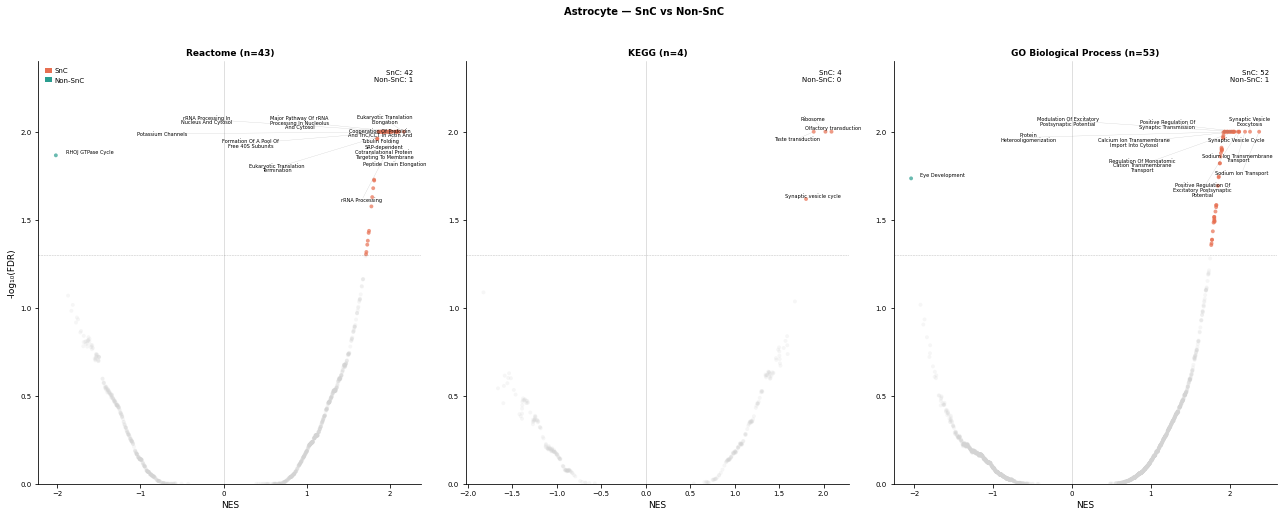

✓ Saved volcano panel


In [15]:
# ============================================================
# Volcano Plots: All Databases (Panel) - Wrapped Labels
# ============================================================

from adjustText import adjust_text
from matplotlib.patches import Patch
import textwrap

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Parameters
CLIP_LOWER = 1e-2
N_LABEL = 10
WRAP_WIDTH = 25  # Characters per line

# Calculate consistent y-axis limit
y_max = 0
for db, res in all_results.items():
    fdr_vals = pd.to_numeric(res['FDR q-val'], errors='coerce').clip(lower=CLIP_LOWER)
    y_max = max(y_max, (-np.log10(fdr_vals)).max())
y_max = y_max * 1.2

for idx, (db, res) in enumerate(all_results.items()):
    ax = axes[idx]
    
    # Prepare data
    plot_df = res.copy()
    plot_df['neg_log10_fdr'] = -np.log10(plot_df['FDR q-val'].clip(lower=CLIP_LOWER))
    
    # Classify
    def classify_pathway(row):
        if row['FDR q-val'] >= FDR_THRESHOLD:
            return 'NS'
        elif row['NES'] > 0:
            return 'Up'
        else:
            return 'Down'
    
    plot_df['Category'] = plot_df.apply(classify_pathway, axis=1)
    
    # Plot
    for cat in ['NS', 'Down', 'Up']:
        subset = plot_df[plot_df['Category'] == cat]
        ax.scatter(
            subset['NES'],
            subset['neg_log10_fdr'],
            c={'Up': COLORS['up'], 'Down': COLORS['down'], 'NS': '#D3D3D3'}[cat],
            alpha=0.7 if cat != 'NS' else 0.2,
            s=15,
            edgecolors='none'
        )
    
    # Reference lines
    fdr_line = -np.log10(FDR_THRESHOLD)
    ax.axhline(fdr_line, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
    
    # Top N labels per direction
    top_up = plot_df[plot_df['Category'] == 'Up'].nlargest(N_LABEL, 'neg_log10_fdr')
    top_down = plot_df[plot_df['Category'] == 'Down'].nlargest(N_LABEL, 'neg_log10_fdr')
    to_label = pd.concat([top_up, top_down])
    
    texts = []
    for _, row in to_label.iterrows():
        # Clean label
        label = row['Term']
        label = label.split(' (GO:')[0]
        label = label.split(' R-HSA-')[0]
        
        # Wrap text
        label = '\n'.join(textwrap.wrap(label, width=WRAP_WIDTH))
        
        texts.append(ax.text(
            row['NES'], 
            row['neg_log10_fdr'], 
            label, 
            fontsize=5,
            linespacing=0.9
        ))
    
    if texts:
        adjust_text(
            texts, 
            ax=ax,
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.3, alpha=0.4),
            expand_points=(3, 3),
            expand_text=(1.5, 1.5),
            force_points=(2, 2),
            force_text=(1, 1),
            time_lim=10
        )
    
    # Consistent axis limits
    ax.set_ylim(0, y_max)
    
    # Styling
    ax.set_xlabel('NES', fontsize=9)
    if idx == 0:
        ax.set_ylabel('-log₁₀(FDR)', fontsize=9)
    
    db_clean = db.replace('_', ' ').replace('2022', '').replace('2021 Human', '').replace('2023', '').strip()
    n_up = (plot_df['Category'] == 'Up').sum()
    n_down = (plot_df['Category'] == 'Down').sum()
    ax.set_title(f'{db_clean} (n={n_up + n_down})', fontsize=9, fontweight='bold')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=7)
    
    # Counts (top right)
    ax.text(0.98, 0.98, f'SnC: {n_up}\nNon-SnC: {n_down}', 
            transform=ax.transAxes, fontsize=7, va='top', ha='right')

# Legend (first panel)
legend_elements = [
    Patch(facecolor=COLORS['up'], label='SnC'),
    Patch(facecolor=COLORS['down'], label='Non-SnC')
]
axes[0].legend(
    handles=legend_elements, 
    loc='upper left',
    frameon=False, 
    fontsize=7,
    handlelength=1,
    handletextpad=0.4
)

plt.suptitle(f'{CELL_TYPE} — SnC vs Non-SnC', fontsize=10, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{DATASET}_{CELL_TYPE.lower()}_gsea_volcano_panel.svg", dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / f"{DATASET}_{CELL_TYPE.lower()}_gsea_volcano_panel.svg", bbox_inches='tight')
plt.show()

print(f"✓ Saved volcano panel")

In [16]:
# ============================================================
# Sankey Diagram: Gene → Pathway → General Category → Cell Type
# FLEXIBLE VERSION - Auto-categorizes based on keywords
# ENLARGED FONTS
# ============================================================

print("=" * 60)
print("CREATING SANKEY DIAGRAM")
print("=" * 60)

try:
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
    print("✓ Plotly loaded")
except ImportError:
    PLOTLY_AVAILABLE = False
    print("✗ Plotly not available")

try:
    import kaleido
    KALEIDO_AVAILABLE = True
    print("✓ Kaleido loaded")
except ImportError:
    KALEIDO_AVAILABLE = False
    print("✗ Kaleido not available")

if PLOTLY_AVAILABLE:
    
    # ------------------------------------------------------------
    # Parameters - CHANGE DATABASE HERE
    # ------------------------------------------------------------
    # DATABASE = 'KEGG_2021_Human'
    # DATABASE = 'GO_Biological_Process_2023'
    DATABASE = 'Reactome_2022'
    
    TOP_N_PATHWAYS = 10
    MAX_GENES_PER_PATHWAY = 5
    MAX_PATHWAY_LEN = 45
    
    DB_DISPLAY = DATABASE.replace('_', ' ').replace('2022', '').replace('2021 Human', '').replace('2023', '').strip()
    
    # ------------------------------------------------------------
    # Keyword-based category mapping (order matters - first match wins)
    # ------------------------------------------------------------
    CATEGORY_KEYWORDS = {
        'Cell Cycle': [
            'cell cycle', 'mitotic', 'mitosis', 'meiosis', 'chromosome segregation',
            'sister chromatid', 'spindle', 'centrosome', 'kinetochore', 'cytokinesis',
            'g1/s', 'g2/m', 's phase', 'cdk', 'cyclin', 'replicat', 'pre-replicat'
        ],
        'DNA Damage Response': [
            'dna repair', 'dna damage', 'double-strand break', 'homologous recombination',
            'base excision', 'nucleotide excision', 'mismatch repair', 'brca', 'atm', 'atr',
            'p53', 'checkpoint', 'd-loop', 'holliday junction'
        ],
        'Apoptosis & Senescence': [
            'apoptosis', 'apoptotic', 'programmed cell death', 'senescence', 'autophagy',
            'necroptosis', 'ferroptosis', 'pyroptosis', 'caspase', 'bcl-2', 'death receptor'
        ],
        'Energy Metabolism': [
            'oxidative phosphorylation', 'electron transport', 'atp synthesis', 'mitochondri',
            'respiratory chain', 'krebs', 'tca cycle', 'citric acid', 'glycolysis', 
            'gluconeogenesis', 'aerobic respiration', 'proton motive'
        ],
        'Lipid Metabolism': [
            'lipid', 'cholesterol', 'fatty acid', 'sphingolipid', 'phospholipid',
            'steroid', 'triglyceride', 'lipoprotein', 'adipogenesis'
        ],
        'Neurotransmitter & Synaptic': [
            'neurotransmitter', 'synaptic', 'synapse', 'gaba', 'glutamate', 'dopamine',
            'serotonin', 'acetylcholine', 'norepinephrine', 'receptor potential',
            'action potential', 'ion channel', 'postsynaptic', 'presynaptic'
        ],
        'Neurodegeneration': [
            'alzheimer', 'parkinson', 'huntington', 'prion', 'amyloid', 'tau protein',
            'neurodegenerat', 'dementia', 'als', 'amyotrophic'
        ],
        'Axon & Myelination': [
            'axon', 'myelination', 'myelin', 'oligodendrocyte', 'schwann', 'nerve growth',
            'neurite', 'dendrit', 'axonogenesis', 'neurogenesis'
        ],
        'Cytoskeleton': [
            'cytoskelet', 'actin', 'microtubule', 'tubulin', 'intermediate filament',
            'polymerization', 'depolymerization', 'motor protein', 'kinesin', 'dynein'
        ],
        'Immune & Inflammation': [
            'immune', 'inflammat', 'cytokine', 'interleukin', 'interferon', 'nf-kb',
            'toll-like', 'complement', 'antigen', 'mhc', 't cell', 'b cell', 'macrophage',
            'neutrophil', 'phagocyt', 'chemokine', 'legionell'
        ],
        'Signal Transduction': [
            'signal', 'mapk', 'erk', 'jnk', 'p38', 'pi3k', 'akt', 'mtor', 'wnt',
            'notch', 'hedgehog', 'tgf-beta', 'bmp', 'jak-stat', 'rho', 'ras',
            'g protein', 'kinase', 'phosphatase', 'calcium', 'camp', 'second messenger'
        ],
        'Vascular & Cardiovascular': [
            'vascular', 'angiogenesis', 'blood vessel', 'endotheli', 'atherosclerosis',
            'cardiac', 'heart', 'artery', 'vein', 'shear stress', 'blood pressure'
        ],
        'Transcription & Epigenetics': [
            'transcription', 'chromatin', 'histone', 'methylation', 'acetylation',
            'epigenetic', 'gene expression', 'promoter', 'enhancer', 'silencing'
        ],
        'Protein Homeostasis': [
            'proteasome', 'ubiquitin', 'protein folding', 'chaperone', 'heat shock',
            'unfolded protein', 'er stress', 'protein degradation', 'autophagy'
        ],
    }
    
    # Direction colors
    DIRECTION_LINK_COLORS = {
        'SnC': 'rgba(231, 111, 81, 0.5)',
        'Non-SnC': 'rgba(42, 157, 143, 0.5)',
    }
    
    # Category colors
    CATEGORY_COLORS = {
        'Cell Cycle': 'rgba(230, 57, 70, 0.85)',
        'DNA Damage Response': 'rgba(247, 127, 0, 0.85)',
        'Apoptosis & Senescence': 'rgba(180, 60, 60, 0.85)',
        'Energy Metabolism': 'rgba(82, 183, 136, 0.85)',
        'Lipid Metabolism': 'rgba(233, 196, 106, 0.85)',
        'Neurotransmitter & Synaptic': 'rgba(42, 157, 143, 0.85)',
        'Neurodegeneration': 'rgba(168, 50, 50, 0.85)',
        'Axon & Myelination': 'rgba(100, 140, 180, 0.85)',
        'Cytoskeleton': 'rgba(52, 78, 65, 0.85)',
        'Immune & Inflammation': 'rgba(218, 165, 32, 0.85)',
        'Signal Transduction': 'rgba(155, 93, 229, 0.85)',
        'Vascular & Cardiovascular': 'rgba(70, 130, 180, 0.85)',
        'Transcription & Epigenetics': 'rgba(147, 112, 219, 0.85)',
        'Protein Homeostasis': 'rgba(60, 179, 113, 0.85)',
        'Other': 'rgba(150, 150, 150, 0.85)',
    }
    
    CATEGORY_LINK_COLORS = {cat: col.replace('0.85', '0.5') for cat, col in CATEGORY_COLORS.items()}
    
    # Cell type colors
    CELLTYPE_COLORS = {
        'Microglia': 'rgba(244, 162, 97, 0.9)',
        'Astrocyte': 'rgba(38, 70, 83, 0.9)',
        'OPC': 'rgba(138, 177, 125, 0.9)'
    }
    CELLTYPE_LINK_COLORS = {
        'Microglia': 'rgba(244, 162, 97, 0.5)',
        'Astrocyte': 'rgba(38, 70, 83, 0.5)',
        'OPC': 'rgba(138, 177, 125, 0.5)'
    }
    
    # ------------------------------------------------------------
    # Auto-categorization function
    # ------------------------------------------------------------
    def get_category(pathway_name):
        """Assign category based on keyword matching."""
        pw_lower = pathway_name.lower().replace('<br>', ' ')
        
        for category, keywords in CATEGORY_KEYWORDS.items():
            for kw in keywords:
                if kw in pw_lower:
                    return category
        return 'Other'
    
    # ------------------------------------------------------------
    # Prepare data
    # ------------------------------------------------------------
    res = all_results[DATABASE].copy()
    res['NES'] = pd.to_numeric(res['NES'], errors='coerce')
    res['FDR q-val'] = pd.to_numeric(res['FDR q-val'], errors='coerce')
    
    sig = res[res['FDR q-val'] < FDR_THRESHOLD].copy()
    sig['Direction'] = sig['NES'].apply(lambda x: 'SnC' if x > 0 else 'Non-SnC')
    
    def clean_pathway(name):
        import re
        name = re.sub(r'\s*R-HSA-\d+$', '', name)
        name = re.sub(r'\s*\(GO:\d+\)$', '', name)
        return name
    
    sig['Pathway'] = sig['Term'].apply(clean_pathway)
    
    def wrap_text(text, max_len=MAX_PATHWAY_LEN):
        if len(text) <= max_len:
            return text
        words = text.split()
        lines = []
        current_line = ""
        for word in words:
            if len(current_line) + len(word) + 1 <= max_len:
                current_line += (" " if current_line else "") + word
            else:
                if current_line:
                    lines.append(current_line)
                current_line = word
        if current_line:
            lines.append(current_line)
        return "<br>".join(lines[:2])
    
    sig_up = sig[sig['NES'] > 0].nlargest(TOP_N_PATHWAYS, 'NES')
    sig_down = sig[sig['NES'] < 0].nsmallest(TOP_N_PATHWAYS, 'NES')
    plot_df = pd.concat([sig_up, sig_down])
    
    print(f"\nDatabase: {DATABASE}")
    print(f"Pathways included: {len(plot_df)}")
    print(f"  SnC: {len(sig_up)}, Non-SnC: {len(sig_down)}")
    
    # Check if we have any data to plot
    if len(plot_df) == 0:
        print("\n⚠ No significant pathways to plot!")
    else:
        # ------------------------------------------------------------
        # Build data structures
        # ------------------------------------------------------------
        snc_genes = []
        nonsnc_genes = []
        snc_pathways = []
        nonsnc_pathways = []
        gene_pathway_links = []
        pathway_direction = {}
        gene_direction = {}
        pathway_to_cat = {}
        
        # Process SnC pathways first
        for _, row in sig_up.iterrows():
            pathway = row['Pathway']
            pathway_wrapped = wrap_text(pathway)
            direction = 'SnC'
            
            if pd.isna(row['Lead_genes']) or row['Lead_genes'] == '':
                continue
            
            genes = [g.strip() for g in row['Lead_genes'].split(';') if g.strip()]
            genes = genes[:MAX_GENES_PER_PATHWAY]
            
            if pathway_wrapped not in snc_pathways:
                snc_pathways.append(pathway_wrapped)
                pathway_direction[pathway_wrapped] = direction
                pathway_to_cat[pathway_wrapped] = get_category(pathway)
            
            for gene in genes:
                if gene not in snc_genes and gene not in nonsnc_genes:
                    snc_genes.append(gene)
                    gene_direction[gene] = direction
                gene_pathway_links.append({
                    'gene': gene,
                    'pathway': pathway_wrapped,
                    'direction': direction,
                    'category': pathway_to_cat[pathway_wrapped]
                })
        
        # Then Non-SnC pathways
        for _, row in sig_down.iterrows():
            pathway = row['Pathway']
            pathway_wrapped = wrap_text(pathway)
            direction = 'Non-SnC'
            
            if pd.isna(row['Lead_genes']) or row['Lead_genes'] == '':
                continue
            
            genes = [g.strip() for g in row['Lead_genes'].split(';') if g.strip()]
            genes = genes[:MAX_GENES_PER_PATHWAY]
            
            if pathway_wrapped not in nonsnc_pathways:
                nonsnc_pathways.append(pathway_wrapped)
                pathway_direction[pathway_wrapped] = direction
                pathway_to_cat[pathway_wrapped] = get_category(pathway)
            
            for gene in genes:
                if gene not in snc_genes and gene not in nonsnc_genes:
                    nonsnc_genes.append(gene)
                    gene_direction[gene] = direction
                gene_pathway_links.append({
                    'gene': gene,
                    'pathway': pathway_wrapped,
                    'direction': direction,
                    'category': pathway_to_cat[pathway_wrapped]
                })
        
        genes_list = snc_genes + nonsnc_genes
        pathways_list = snc_pathways + nonsnc_pathways
        
        # Get only categories that are actually used
        categories_used = []
        for cat in CATEGORY_COLORS.keys():
            if cat in pathway_to_cat.values():
                categories_used.append(cat)
        
        categories_list = categories_used
        celltype_list = [CELL_TYPE]
        
        print(f"Genes: {len(genes_list)} ({len(snc_genes)} SnC, {len(nonsnc_genes)} Non-SnC)")
        print(f"Pathways: {len(pathways_list)} ({len(snc_pathways)} SnC, {len(nonsnc_pathways)} Non-SnC)")
        print(f"Categories: {categories_list}")
        
        # Print pathway -> category mapping for verification
        print("\nPathway → Category mapping:")
        for pw, cat in pathway_to_cat.items():
            print(f"  {pw[:50]}... → {cat}")
        
        # ------------------------------------------------------------
        # Create node indices
        # ------------------------------------------------------------
        node_labels = genes_list + pathways_list + categories_list + celltype_list
        
        gene_idx = {g: i for i, g in enumerate(genes_list)}
        pathway_idx = {p: i + len(genes_list) for i, p in enumerate(pathways_list)}
        category_idx = {c: i + len(genes_list) + len(pathways_list) for i, c in enumerate(categories_list)}
        celltype_idx = {ct: i + len(genes_list) + len(pathways_list) + len(categories_list) for i, ct in enumerate(celltype_list)}
        
        # ------------------------------------------------------------
        # Set node positions
        # ------------------------------------------------------------
        node_x = []
        node_y = []
        
        # Column x-positions
        X_GENES = 0.01
        X_PATHWAYS = 0.30
        X_CATEGORIES = 0.65
        X_CELLTYPE = 0.99
        
        n_genes = len(genes_list)
        for i in range(n_genes):
            node_x.append(X_GENES)
            node_y.append((i + 0.5) / n_genes)
        
        n_pathways = len(pathways_list)
        for i in range(n_pathways):
            node_x.append(X_PATHWAYS)
            node_y.append((i + 0.5) / n_pathways)
        
        n_categories = len(categories_list)
        for i in range(n_categories):
            node_x.append(X_CATEGORIES)
            # Wider spread: use 0.05 to 0.95 range for better separation
            node_y.append(0.05 + (i * 0.90 / max(n_categories - 1, 1)))
        
        for i in range(len(celltype_list)):
            node_x.append(X_CELLTYPE)
            node_y.append(0.5)
        
        # ------------------------------------------------------------
        # Build links
        # ------------------------------------------------------------
        sources = []
        targets = []
        values = []
        link_colors = []
        
        # 1) Gene → Pathway: color by DIRECTION
        gene_to_pathway = {}
        for link in gene_pathway_links:
            key = (link['gene'], link['pathway'])
            if key not in gene_to_pathway:
                gene_to_pathway[key] = {'count': 0, 'direction': link['direction']}
            gene_to_pathway[key]['count'] += 1
        
        for (gene, pathway), data in gene_to_pathway.items():
            sources.append(gene_idx[gene])
            targets.append(pathway_idx[pathway])
            values.append(data['count'])
            link_colors.append(DIRECTION_LINK_COLORS.get(data['direction'], 'rgba(150,150,150,0.4)'))
        
        # 2) Pathway → Category: color by CATEGORY
        pathway_to_category_links = {}
        for link in gene_pathway_links:
            pw = link['pathway']
            cat = link['category']
            key = (pw, cat)
            if key not in pathway_to_category_links:
                pathway_to_category_links[key] = {'count': 0, 'category': cat}
            pathway_to_category_links[key]['count'] += 1
        
        for (pathway, category), data in pathway_to_category_links.items():
            if category in category_idx:
                sources.append(pathway_idx[pathway])
                targets.append(category_idx[category])
                values.append(data['count'])
                link_colors.append(CATEGORY_LINK_COLORS.get(data['category'], 'rgba(150,150,150,0.4)'))
        
        # 3) Category → Cell Type: color by CELL TYPE
        category_to_celltype = {}
        for link in gene_pathway_links:
            cat = link['category']
            key = (cat, CELL_TYPE)
            if key not in category_to_celltype:
                category_to_celltype[key] = {'count': 0}
            category_to_celltype[key]['count'] += 1
        
        for (category, celltype), data in category_to_celltype.items():
            if category in category_idx:
                sources.append(category_idx[category])
                targets.append(celltype_idx[celltype])
                values.append(data['count'])
                link_colors.append(CELLTYPE_LINK_COLORS.get(celltype, 'rgba(150,150,150,0.4)'))
        
        # ------------------------------------------------------------
        # Node colors
        # ------------------------------------------------------------
        node_colors = []
        
        # Genes: colored by direction
        for gene in genes_list:
            direction = gene_direction.get(gene, 'Non-SnC')
            if direction == 'SnC':
                node_colors.append('rgba(231, 111, 81, 0.8)')
            else:
                node_colors.append('rgba(42, 157, 143, 0.8)')
        
        # Pathways: colored by category
        for pathway in pathways_list:
            cat = pathway_to_cat.get(pathway, 'Other')
            color = CATEGORY_COLORS.get(cat, 'rgba(150, 150, 150, 0.8)')
            node_colors.append(color)
        
        # Categories: unique colors
        for cat in categories_list:
            node_colors.append(CATEGORY_COLORS.get(cat, 'rgba(150, 150, 150, 0.85)'))
        
        # Cell type
        for ct in celltype_list:
            node_colors.append(CELLTYPE_COLORS.get(ct, 'rgba(150, 150, 150, 0.9)'))
        
        # ------------------------------------------------------------
        # Create Sankey figure
        # ------------------------------------------------------------
        fig = go.Figure(data=[go.Sankey(
            arrangement='fixed',
            node=dict(
                pad=15,
                thickness=12,
                line=dict(color='white', width=0.5),
                label=node_labels,
                color=node_colors,
                x=node_x,
                y=node_y
            ),
            link=dict(
                source=sources,
                target=targets,
                value=values,
                color=link_colors
            )
        )])
        
        fig.update_layout(
            font=dict(size=12, family='Arial'),  # BASE FONT: 9 → 12 (node labels)
            height=950,
            width=1600,
            paper_bgcolor='white',
            plot_bgcolor='white',
            margin=dict(t=100, l=60, r=50, b=50)  # Increased margins for larger text
        )
        
        # ------------------------------------------------------------
        # Main title - compact
        # ------------------------------------------------------------
        fig.add_annotation(
            x=0.5, y=1.06,
            xref='paper', yref='paper',
            text=f'<b>{CELL_TYPE}: GSEA Prerank Pathway Analysis</b> | {DB_DISPLAY} | Top {TOP_N_PATHWAYS}/direction | FDR < {FDR_THRESHOLD}',
            showarrow=False,
            font=dict(size=20),  # TITLE: 16 → 20
            xanchor='center',
            yanchor='bottom'
        )
        
        # ------------------------------------------------------------
        # Column labels - COMPACT, LARGER FONT, CENTER JUSTIFIED
        # ------------------------------------------------------------
        col_centers = [
            X_GENES + 0.04,
            X_PATHWAYS + 0.10,
            X_CATEGORIES + 0.08,
            X_CELLTYPE,
        ]
        
        # Adjust column label for database
        if 'KEGG' in DATABASE:
            pathway_label = '<b>Pathways</b> (KEGG)'
        elif 'GO' in DATABASE:
            pathway_label = '<b>Pathways</b> (GO BP)'
        elif 'Reactome' in DATABASE:
            pathway_label = '<b>Pathways</b> (Reactome)'
        else:
            pathway_label = '<b>Pathways</b>'
        
        column_labels = [
            '<b>Genes</b> (Leading Edge)',
            pathway_label,
            '<b>Categories</b>',
            f'<b>Cell Type</b> ({CELL_TYPE})',
        ]
        
        for x_pos, label in zip(col_centers, column_labels):
            fig.add_annotation(
                x=x_pos, y=1.02,
                xref='paper', yref='paper',
                text=label,
                showarrow=False,
                font=dict(size=16),  # COLUMN HEADERS: 13 → 16
                xanchor='center',
                yanchor='bottom'
            )
        
        # ------------------------------------------------------------
        # Direction labels (SnC / Non-SnC) - LARGER FONT, CLOSER
        # ------------------------------------------------------------
        if len(snc_genes) > 0 and len(nonsnc_genes) > 0:
            snc_mid_y = (len(snc_genes) / 2) / n_genes
            nonsnc_mid_y = (len(snc_genes) + len(nonsnc_genes) / 2) / n_genes
            
            fig.add_annotation(
                x=-0.005, y=1 - snc_mid_y,
                xref='paper', yref='paper',
                text='<b>SnC</b>',
                showarrow=False,
                font=dict(size=16, color='rgb(231, 111, 81)'),  # ROW LABELS: 14 → 16
                xanchor='right',
                yanchor='middle',
                textangle=-90
            )
            
            fig.add_annotation(
                x=-0.005, y=1 - nonsnc_mid_y,
                xref='paper', yref='paper',
                text='<b>Non-SnC</b>',
                showarrow=False,
                font=dict(size=16, color='rgb(42, 157, 143)'),  # ROW LABELS: 14 → 16
                xanchor='right',
                yanchor='middle',
                textangle=-90
            )
        elif len(snc_genes) > 0:
            fig.add_annotation(
                x=-0.005, y=0.5,
                xref='paper', yref='paper',
                text='<b>SnC</b>',
                showarrow=False,
                font=dict(size=16, color='rgb(231, 111, 81)'),  # ROW LABELS: 14 → 16
                xanchor='right',
                yanchor='middle',
                textangle=-90
            )
        elif len(nonsnc_genes) > 0:
            fig.add_annotation(
                x=-0.005, y=0.5,
                xref='paper', yref='paper',
                text='<b>Non-SnC</b>',
                showarrow=False,
                font=dict(size=16, color='rgb(42, 157, 143)'),  # ROW LABELS: 14 → 16
                xanchor='right',
                yanchor='middle',
                textangle=-90
            )
        
        # ------------------------------------------------------------
        # Footer - compact
        # ------------------------------------------------------------
        fig.add_annotation(
            x=0.5, y=-0.03,
            xref='paper', yref='paper',
            text='<i>Links: Gene→Pathway (direction) | Pathway→Category (category) | Category→Cell Type (cell type)</i>',
            showarrow=False,
            font=dict(size=11, color='gray'),  # FOOTER: 9 → 11
            xanchor='center',
            yanchor='top'
        )
        
        # ------------------------------------------------------------
        # Save outputs
        # ------------------------------------------------------------
        db_short = DATABASE.replace('_2022', '').replace('_2021_Human', '').replace('_2023', '').lower()
        
        sankey_html = FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_{db_short}_gsea_sankey.html'
        fig.write_html(sankey_html)
        print(f"\n✓ Saved: {sankey_html.name}")
        
        if KALEIDO_AVAILABLE:
            sankey_png = FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_{db_short}_gsea_sankey.svg'
            sankey_pdf = FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_{db_short}_gsea_sankey.svg'
            
            fig.write_image(sankey_png, scale=2)
            print(f"✓ Saved: {sankey_png.name}")
            
            fig.write_image(sankey_pdf, scale=2)
            print(f"✓ Saved: {sankey_pdf.name}")
        
        fig.show()
        
        print("\n✓ Sankey diagram complete")

else:
    print("\nSkipping Sankey - Plotly not available")

CREATING SANKEY DIAGRAM
✓ Plotly loaded
✓ Kaleido loaded

Database: Reactome_2022
Pathways included: 11
  SnC: 10, Non-SnC: 1
Genes: 28 (23 SnC, 5 Non-SnC)
Pathways: 11 (10 SnC, 1 Non-SnC)
Categories: ['Cytoskeleton', 'Signal Transduction', 'Other']

Pathway → Category mapping:
  Eukaryotic Translation Elongation... → Other
  Peptide Chain Elongation... → Other
  rRNA Processing... → Other
  Major Pathway Of rRNA Processing In Nucleolus<br>A... → Other
  rRNA Processing In Nucleus And Cytosol... → Other
  SRP-dependent Cotranslational Protein<br>Targeting... → Other
  Eukaryotic Translation Termination... → Other
  Cooperation Of Prefoldin And TriC/CCT In<br>Actin ... → Cytoskeleton
  Formation Of A Pool Of Free 40S Subunits... → Other
  Potassium Channels... → Other
  RHOJ GTPase Cycle... → Signal Transduction

✓ Saved: psychad_aging_astrocyte_reactome_gsea_sankey.html
✓ Saved: psychad_aging_astrocyte_reactome_gsea_sankey.svg
✓ Saved: psychad_aging_astrocyte_reactome_gsea_sankey.svg



✓ Sankey diagram complete


In [17]:
# ============================================================
# Sankey Diagram: Gene → Pathway → General Category → Cell Type
# FLEXIBLE VERSION - Auto-categorizes based on keywords
# ENLARGED FONTS
# ============================================================

print("=" * 60)
print("CREATING SANKEY DIAGRAM")
print("=" * 60)

try:
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
    print("✓ Plotly loaded")
except ImportError:
    PLOTLY_AVAILABLE = False
    print("✗ Plotly not available")

try:
    import kaleido
    KALEIDO_AVAILABLE = True
    print("✓ Kaleido loaded")
except ImportError:
    KALEIDO_AVAILABLE = False
    print("✗ Kaleido not available")

if PLOTLY_AVAILABLE:
    
    # ------------------------------------------------------------
    # Parameters - CHANGE DATABASE HERE
    # ------------------------------------------------------------
    # DATABASE = 'KEGG_2021_Human'
    DATABASE = 'GO_Biological_Process_2023'
    # DATABASE = 'Reactome_2022'
    
    TOP_N_PATHWAYS = 10
    MAX_GENES_PER_PATHWAY = 5
    MAX_PATHWAY_LEN = 45
    
    DB_DISPLAY = DATABASE.replace('_', ' ').replace('2022', '').replace('2021 Human', '').replace('2023', '').strip()
    
    # ------------------------------------------------------------
    # Keyword-based category mapping (order matters - first match wins)
    # ------------------------------------------------------------
    CATEGORY_KEYWORDS = {
        'Cell Cycle': [
            'cell cycle', 'mitotic', 'mitosis', 'meiosis', 'chromosome segregation',
            'sister chromatid', 'spindle', 'centrosome', 'kinetochore', 'cytokinesis',
            'g1/s', 'g2/m', 's phase', 'cdk', 'cyclin', 'replicat', 'pre-replicat'
        ],
        'DNA Damage Response': [
            'dna repair', 'dna damage', 'double-strand break', 'homologous recombination',
            'base excision', 'nucleotide excision', 'mismatch repair', 'brca', 'atm', 'atr',
            'p53', 'checkpoint', 'd-loop', 'holliday junction'
        ],
        'Apoptosis & Senescence': [
            'apoptosis', 'apoptotic', 'programmed cell death', 'senescence', 'autophagy',
            'necroptosis', 'ferroptosis', 'pyroptosis', 'caspase', 'bcl-2', 'death receptor'
        ],
        'Energy Metabolism': [
            'oxidative phosphorylation', 'electron transport', 'atp synthesis', 'mitochondri',
            'respiratory chain', 'krebs', 'tca cycle', 'citric acid', 'glycolysis', 
            'gluconeogenesis', 'aerobic respiration', 'proton motive'
        ],
        'Lipid Metabolism': [
            'lipid', 'cholesterol', 'fatty acid', 'sphingolipid', 'phospholipid',
            'steroid', 'triglyceride', 'lipoprotein', 'adipogenesis'
        ],
        'Neurotransmitter & Synaptic': [
            'neurotransmitter', 'synaptic', 'synapse', 'gaba', 'glutamate', 'dopamine',
            'serotonin', 'acetylcholine', 'norepinephrine', 'receptor potential',
            'action potential', 'ion channel', 'postsynaptic', 'presynaptic'
        ],
        'Neurodegeneration': [
            'alzheimer', 'parkinson', 'huntington', 'prion', 'amyloid', 'tau protein',
            'neurodegenerat', 'dementia', 'als', 'amyotrophic'
        ],
        'Axon & Myelination': [
            'axon', 'myelination', 'myelin', 'oligodendrocyte', 'schwann', 'nerve growth',
            'neurite', 'dendrit', 'axonogenesis', 'neurogenesis'
        ],
        'Cytoskeleton': [
            'cytoskelet', 'actin', 'microtubule', 'tubulin', 'intermediate filament',
            'polymerization', 'depolymerization', 'motor protein', 'kinesin', 'dynein'
        ],
        'Immune & Inflammation': [
            'immune', 'inflammat', 'cytokine', 'interleukin', 'interferon', 'nf-kb',
            'toll-like', 'complement', 'antigen', 'mhc', 't cell', 'b cell', 'macrophage',
            'neutrophil', 'phagocyt', 'chemokine', 'legionell'
        ],
        'Signal Transduction': [
            'signal', 'mapk', 'erk', 'jnk', 'p38', 'pi3k', 'akt', 'mtor', 'wnt',
            'notch', 'hedgehog', 'tgf-beta', 'bmp', 'jak-stat', 'rho', 'ras',
            'g protein', 'kinase', 'phosphatase', 'calcium', 'camp', 'second messenger'
        ],
        'Vascular & Cardiovascular': [
            'vascular', 'angiogenesis', 'blood vessel', 'endotheli', 'atherosclerosis',
            'cardiac', 'heart', 'artery', 'vein', 'shear stress', 'blood pressure'
        ],
        'Transcription & Epigenetics': [
            'transcription', 'chromatin', 'histone', 'methylation', 'acetylation',
            'epigenetic', 'gene expression', 'promoter', 'enhancer', 'silencing'
        ],
        'Protein Homeostasis': [
            'proteasome', 'ubiquitin', 'protein folding', 'chaperone', 'heat shock',
            'unfolded protein', 'er stress', 'protein degradation', 'autophagy'
        ],
    }
    
    # Direction colors
    DIRECTION_LINK_COLORS = {
        'SnC': 'rgba(231, 111, 81, 0.5)',
        'Non-SnC': 'rgba(42, 157, 143, 0.5)',
    }
    
    # Category colors
    CATEGORY_COLORS = {
        'Cell Cycle': 'rgba(230, 57, 70, 0.85)',
        'DNA Damage Response': 'rgba(247, 127, 0, 0.85)',
        'Apoptosis & Senescence': 'rgba(180, 60, 60, 0.85)',
        'Energy Metabolism': 'rgba(82, 183, 136, 0.85)',
        'Lipid Metabolism': 'rgba(233, 196, 106, 0.85)',
        'Neurotransmitter & Synaptic': 'rgba(42, 157, 143, 0.85)',
        'Neurodegeneration': 'rgba(168, 50, 50, 0.85)',
        'Axon & Myelination': 'rgba(100, 140, 180, 0.85)',
        'Cytoskeleton': 'rgba(52, 78, 65, 0.85)',
        'Immune & Inflammation': 'rgba(218, 165, 32, 0.85)',
        'Signal Transduction': 'rgba(155, 93, 229, 0.85)',
        'Vascular & Cardiovascular': 'rgba(70, 130, 180, 0.85)',
        'Transcription & Epigenetics': 'rgba(147, 112, 219, 0.85)',
        'Protein Homeostasis': 'rgba(60, 179, 113, 0.85)',
        'Other': 'rgba(150, 150, 150, 0.85)',
    }
    
    CATEGORY_LINK_COLORS = {cat: col.replace('0.85', '0.5') for cat, col in CATEGORY_COLORS.items()}
    
    # Cell type colors
    CELLTYPE_COLORS = {
        'Microglia': 'rgba(244, 162, 97, 0.9)',
        'Astrocyte': 'rgba(38, 70, 83, 0.9)',
        'OPC': 'rgba(138, 177, 125, 0.9)'
    }
    CELLTYPE_LINK_COLORS = {
        'Microglia': 'rgba(244, 162, 97, 0.5)',
        'Astrocyte': 'rgba(38, 70, 83, 0.5)',
        'OPC': 'rgba(138, 177, 125, 0.5)'
    }
    
    # ------------------------------------------------------------
    # Auto-categorization function
    # ------------------------------------------------------------
    def get_category(pathway_name):
        """Assign category based on keyword matching."""
        pw_lower = pathway_name.lower().replace('<br>', ' ')
        
        for category, keywords in CATEGORY_KEYWORDS.items():
            for kw in keywords:
                if kw in pw_lower:
                    return category
        return 'Other'
    
    # ------------------------------------------------------------
    # Prepare data
    # ------------------------------------------------------------
    res = all_results[DATABASE].copy()
    res['NES'] = pd.to_numeric(res['NES'], errors='coerce')
    res['FDR q-val'] = pd.to_numeric(res['FDR q-val'], errors='coerce')
    
    sig = res[res['FDR q-val'] < FDR_THRESHOLD].copy()
    sig['Direction'] = sig['NES'].apply(lambda x: 'SnC' if x > 0 else 'Non-SnC')
    
    def clean_pathway(name):
        import re
        name = re.sub(r'\s*R-HSA-\d+$', '', name)
        name = re.sub(r'\s*\(GO:\d+\)$', '', name)
        return name
    
    sig['Pathway'] = sig['Term'].apply(clean_pathway)
    
    def wrap_text(text, max_len=MAX_PATHWAY_LEN):
        if len(text) <= max_len:
            return text
        words = text.split()
        lines = []
        current_line = ""
        for word in words:
            if len(current_line) + len(word) + 1 <= max_len:
                current_line += (" " if current_line else "") + word
            else:
                if current_line:
                    lines.append(current_line)
                current_line = word
        if current_line:
            lines.append(current_line)
        return "<br>".join(lines[:2])
    
    sig_up = sig[sig['NES'] > 0].nlargest(TOP_N_PATHWAYS, 'NES')
    sig_down = sig[sig['NES'] < 0].nsmallest(TOP_N_PATHWAYS, 'NES')
    plot_df = pd.concat([sig_up, sig_down])
    
    print(f"\nDatabase: {DATABASE}")
    print(f"Pathways included: {len(plot_df)}")
    print(f"  SnC: {len(sig_up)}, Non-SnC: {len(sig_down)}")
    
    # Check if we have any data to plot
    if len(plot_df) == 0:
        print("\n⚠ No significant pathways to plot!")
    else:
        # ------------------------------------------------------------
        # Build data structures
        # ------------------------------------------------------------
        snc_genes = []
        nonsnc_genes = []
        snc_pathways = []
        nonsnc_pathways = []
        gene_pathway_links = []
        pathway_direction = {}
        gene_direction = {}
        pathway_to_cat = {}
        
        # Process SnC pathways first
        for _, row in sig_up.iterrows():
            pathway = row['Pathway']
            pathway_wrapped = wrap_text(pathway)
            direction = 'SnC'
            
            if pd.isna(row['Lead_genes']) or row['Lead_genes'] == '':
                continue
            
            genes = [g.strip() for g in row['Lead_genes'].split(';') if g.strip()]
            genes = genes[:MAX_GENES_PER_PATHWAY]
            
            if pathway_wrapped not in snc_pathways:
                snc_pathways.append(pathway_wrapped)
                pathway_direction[pathway_wrapped] = direction
                pathway_to_cat[pathway_wrapped] = get_category(pathway)
            
            for gene in genes:
                if gene not in snc_genes and gene not in nonsnc_genes:
                    snc_genes.append(gene)
                    gene_direction[gene] = direction
                gene_pathway_links.append({
                    'gene': gene,
                    'pathway': pathway_wrapped,
                    'direction': direction,
                    'category': pathway_to_cat[pathway_wrapped]
                })
        
        # Then Non-SnC pathways
        for _, row in sig_down.iterrows():
            pathway = row['Pathway']
            pathway_wrapped = wrap_text(pathway)
            direction = 'Non-SnC'
            
            if pd.isna(row['Lead_genes']) or row['Lead_genes'] == '':
                continue
            
            genes = [g.strip() for g in row['Lead_genes'].split(';') if g.strip()]
            genes = genes[:MAX_GENES_PER_PATHWAY]
            
            if pathway_wrapped not in nonsnc_pathways:
                nonsnc_pathways.append(pathway_wrapped)
                pathway_direction[pathway_wrapped] = direction
                pathway_to_cat[pathway_wrapped] = get_category(pathway)
            
            for gene in genes:
                if gene not in snc_genes and gene not in nonsnc_genes:
                    nonsnc_genes.append(gene)
                    gene_direction[gene] = direction
                gene_pathway_links.append({
                    'gene': gene,
                    'pathway': pathway_wrapped,
                    'direction': direction,
                    'category': pathway_to_cat[pathway_wrapped]
                })
        
        genes_list = snc_genes + nonsnc_genes
        pathways_list = snc_pathways + nonsnc_pathways
        
        # Get only categories that are actually used
        categories_used = []
        for cat in CATEGORY_COLORS.keys():
            if cat in pathway_to_cat.values():
                categories_used.append(cat)
        
        categories_list = categories_used
        celltype_list = [CELL_TYPE]
        
        print(f"Genes: {len(genes_list)} ({len(snc_genes)} SnC, {len(nonsnc_genes)} Non-SnC)")
        print(f"Pathways: {len(pathways_list)} ({len(snc_pathways)} SnC, {len(nonsnc_pathways)} Non-SnC)")
        print(f"Categories: {categories_list}")
        
        # Print pathway -> category mapping for verification
        print("\nPathway → Category mapping:")
        for pw, cat in pathway_to_cat.items():
            print(f"  {pw[:50]}... → {cat}")
        
        # ------------------------------------------------------------
        # Create node indices
        # ------------------------------------------------------------
        node_labels = genes_list + pathways_list + categories_list + celltype_list
        
        gene_idx = {g: i for i, g in enumerate(genes_list)}
        pathway_idx = {p: i + len(genes_list) for i, p in enumerate(pathways_list)}
        category_idx = {c: i + len(genes_list) + len(pathways_list) for i, c in enumerate(categories_list)}
        celltype_idx = {ct: i + len(genes_list) + len(pathways_list) + len(categories_list) for i, ct in enumerate(celltype_list)}
        
        # ------------------------------------------------------------
        # Set node positions
        # ------------------------------------------------------------
        node_x = []
        node_y = []
        
        # Column x-positions
        X_GENES = 0.01
        X_PATHWAYS = 0.30
        X_CATEGORIES = 0.65
        X_CELLTYPE = 0.99
        
        n_genes = len(genes_list)
        for i in range(n_genes):
            node_x.append(X_GENES)
            node_y.append((i + 0.5) / n_genes)
        
        n_pathways = len(pathways_list)
        for i in range(n_pathways):
            node_x.append(X_PATHWAYS)
            node_y.append((i + 0.5) / n_pathways)
        
        n_categories = len(categories_list)
        for i in range(n_categories):
            node_x.append(X_CATEGORIES)
            # Wider spread: use 0.05 to 0.95 range for better separation
            node_y.append(0.05 + (i * 0.90 / max(n_categories - 1, 1)))
        
        for i in range(len(celltype_list)):
            node_x.append(X_CELLTYPE)
            node_y.append(0.5)
        
        # ------------------------------------------------------------
        # Build links
        # ------------------------------------------------------------
        sources = []
        targets = []
        values = []
        link_colors = []
        
        # 1) Gene → Pathway: color by DIRECTION
        gene_to_pathway = {}
        for link in gene_pathway_links:
            key = (link['gene'], link['pathway'])
            if key not in gene_to_pathway:
                gene_to_pathway[key] = {'count': 0, 'direction': link['direction']}
            gene_to_pathway[key]['count'] += 1
        
        for (gene, pathway), data in gene_to_pathway.items():
            sources.append(gene_idx[gene])
            targets.append(pathway_idx[pathway])
            values.append(data['count'])
            link_colors.append(DIRECTION_LINK_COLORS.get(data['direction'], 'rgba(150,150,150,0.4)'))
        
        # 2) Pathway → Category: color by CATEGORY
        pathway_to_category_links = {}
        for link in gene_pathway_links:
            pw = link['pathway']
            cat = link['category']
            key = (pw, cat)
            if key not in pathway_to_category_links:
                pathway_to_category_links[key] = {'count': 0, 'category': cat}
            pathway_to_category_links[key]['count'] += 1
        
        for (pathway, category), data in pathway_to_category_links.items():
            if category in category_idx:
                sources.append(pathway_idx[pathway])
                targets.append(category_idx[category])
                values.append(data['count'])
                link_colors.append(CATEGORY_LINK_COLORS.get(data['category'], 'rgba(150,150,150,0.4)'))
        
        # 3) Category → Cell Type: color by CELL TYPE
        category_to_celltype = {}
        for link in gene_pathway_links:
            cat = link['category']
            key = (cat, CELL_TYPE)
            if key not in category_to_celltype:
                category_to_celltype[key] = {'count': 0}
            category_to_celltype[key]['count'] += 1
        
        for (category, celltype), data in category_to_celltype.items():
            if category in category_idx:
                sources.append(category_idx[category])
                targets.append(celltype_idx[celltype])
                values.append(data['count'])
                link_colors.append(CELLTYPE_LINK_COLORS.get(celltype, 'rgba(150,150,150,0.4)'))
        
        # ------------------------------------------------------------
        # Node colors
        # ------------------------------------------------------------
        node_colors = []
        
        # Genes: colored by direction
        for gene in genes_list:
            direction = gene_direction.get(gene, 'Non-SnC')
            if direction == 'SnC':
                node_colors.append('rgba(231, 111, 81, 0.8)')
            else:
                node_colors.append('rgba(42, 157, 143, 0.8)')
        
        # Pathways: colored by category
        for pathway in pathways_list:
            cat = pathway_to_cat.get(pathway, 'Other')
            color = CATEGORY_COLORS.get(cat, 'rgba(150, 150, 150, 0.8)')
            node_colors.append(color)
        
        # Categories: unique colors
        for cat in categories_list:
            node_colors.append(CATEGORY_COLORS.get(cat, 'rgba(150, 150, 150, 0.85)'))
        
        # Cell type
        for ct in celltype_list:
            node_colors.append(CELLTYPE_COLORS.get(ct, 'rgba(150, 150, 150, 0.9)'))
        
        # ------------------------------------------------------------
        # Create Sankey figure
        # ------------------------------------------------------------
        fig = go.Figure(data=[go.Sankey(
            arrangement='fixed',
            node=dict(
                pad=15,
                thickness=12,
                line=dict(color='white', width=0.5),
                label=node_labels,
                color=node_colors,
                x=node_x,
                y=node_y
            ),
            link=dict(
                source=sources,
                target=targets,
                value=values,
                color=link_colors
            )
        )])
        
        fig.update_layout(
            font=dict(size=12, family='Arial'),  # BASE FONT: 9 → 12 (node labels)
            height=950,
            width=1600,
            paper_bgcolor='white',
            plot_bgcolor='white',
            margin=dict(t=100, l=60, r=50, b=50)  # Increased margins for larger text
        )
        
        # ------------------------------------------------------------
        # Main title - compact
        # ------------------------------------------------------------
        fig.add_annotation(
            x=0.5, y=1.06,
            xref='paper', yref='paper',
            text=f'<b>{CELL_TYPE}: GSEA Prerank Pathway Analysis</b> | {DB_DISPLAY} | Top {TOP_N_PATHWAYS}/direction | FDR < {FDR_THRESHOLD}',
            showarrow=False,
            font=dict(size=20),  # TITLE: 16 → 20
            xanchor='center',
            yanchor='bottom'
        )
        
        # ------------------------------------------------------------
        # Column labels - COMPACT, LARGER FONT, CENTER JUSTIFIED
        # ------------------------------------------------------------
        col_centers = [
            X_GENES + 0.04,
            X_PATHWAYS + 0.10,
            X_CATEGORIES + 0.08,
            X_CELLTYPE,
        ]
        
        # Adjust column label for database
        if 'KEGG' in DATABASE:
            pathway_label = '<b>Pathways</b> (KEGG)'
        elif 'GO' in DATABASE:
            pathway_label = '<b>Pathways</b> (GO BP)'
        elif 'Reactome' in DATABASE:
            pathway_label = '<b>Pathways</b> (Reactome)'
        else:
            pathway_label = '<b>Pathways</b>'
        
        column_labels = [
            '<b>Genes</b> (Leading Edge)',
            pathway_label,
            '<b>Categories</b>',
            f'<b>Cell Type</b> ({CELL_TYPE})',
        ]
        
        for x_pos, label in zip(col_centers, column_labels):
            fig.add_annotation(
                x=x_pos, y=1.02,
                xref='paper', yref='paper',
                text=label,
                showarrow=False,
                font=dict(size=16),  # COLUMN HEADERS: 13 → 16
                xanchor='center',
                yanchor='bottom'
            )
        
        # ------------------------------------------------------------
        # Direction labels (SnC / Non-SnC) - LARGER FONT, CLOSER
        # ------------------------------------------------------------
        if len(snc_genes) > 0 and len(nonsnc_genes) > 0:
            snc_mid_y = (len(snc_genes) / 2) / n_genes
            nonsnc_mid_y = (len(snc_genes) + len(nonsnc_genes) / 2) / n_genes
            
            fig.add_annotation(
                x=-0.005, y=1 - snc_mid_y,
                xref='paper', yref='paper',
                text='<b>SnC</b>',
                showarrow=False,
                font=dict(size=16, color='rgb(231, 111, 81)'),  # ROW LABELS: 14 → 16
                xanchor='right',
                yanchor='middle',
                textangle=-90
            )
            
            fig.add_annotation(
                x=-0.005, y=1 - nonsnc_mid_y,
                xref='paper', yref='paper',
                text='<b>Non-SnC</b>',
                showarrow=False,
                font=dict(size=16, color='rgb(42, 157, 143)'),  # ROW LABELS: 14 → 16
                xanchor='right',
                yanchor='middle',
                textangle=-90
            )
        elif len(snc_genes) > 0:
            fig.add_annotation(
                x=-0.005, y=0.5,
                xref='paper', yref='paper',
                text='<b>SnC</b>',
                showarrow=False,
                font=dict(size=16, color='rgb(231, 111, 81)'),  # ROW LABELS: 14 → 16
                xanchor='right',
                yanchor='middle',
                textangle=-90
            )
        elif len(nonsnc_genes) > 0:
            fig.add_annotation(
                x=-0.005, y=0.5,
                xref='paper', yref='paper',
                text='<b>Non-SnC</b>',
                showarrow=False,
                font=dict(size=16, color='rgb(42, 157, 143)'),  # ROW LABELS: 14 → 16
                xanchor='right',
                yanchor='middle',
                textangle=-90
            )
        
        # ------------------------------------------------------------
        # Footer - compact
        # ------------------------------------------------------------
        fig.add_annotation(
            x=0.5, y=-0.03,
            xref='paper', yref='paper',
            text='<i>Links: Gene→Pathway (direction) | Pathway→Category (category) | Category→Cell Type (cell type)</i>',
            showarrow=False,
            font=dict(size=11, color='gray'),  # FOOTER: 9 → 11
            xanchor='center',
            yanchor='top'
        )
        
        # ------------------------------------------------------------
        # Save outputs
        # ------------------------------------------------------------
        db_short = DATABASE.replace('_2022', '').replace('_2021_Human', '').replace('_2023', '').lower()
        
        sankey_html = FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_{db_short}_gsea_sankey.html'
        fig.write_html(sankey_html)
        print(f"\n✓ Saved: {sankey_html.name}")
        
        if KALEIDO_AVAILABLE:
            sankey_png = FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_{db_short}_gsea_sankey.svg'
            sankey_pdf = FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_{db_short}_gsea_sankey.svg'
            
            fig.write_image(sankey_png, scale=2)
            print(f"✓ Saved: {sankey_png.name}")
            
            fig.write_image(sankey_pdf, scale=2)
            print(f"✓ Saved: {sankey_pdf.name}")
        
        fig.show()
        
        print("\n✓ Sankey diagram complete")

else:
    print("\nSkipping Sankey - Plotly not available")

CREATING SANKEY DIAGRAM
✓ Plotly loaded
✓ Kaleido loaded

Database: GO_Biological_Process_2023
Pathways included: 11
  SnC: 10, Non-SnC: 1
Genes: 32 (27 SnC, 5 Non-SnC)
Pathways: 11 (10 SnC, 1 Non-SnC)
Categories: ['Neurotransmitter & Synaptic', 'Signal Transduction', 'Other']

Pathway → Category mapping:
  Sodium Ion Transport... → Other
  Synaptic Vesicle Exocytosis... → Neurotransmitter & Synaptic
  Sodium Ion Transmembrane Transport... → Other
  Synaptic Vesicle Cycle... → Neurotransmitter & Synaptic
  Positive Regulation Of Synaptic Transmission... → Neurotransmitter & Synaptic
  Positive Regulation Of Excitatory<br>Postsynaptic ... → Neurotransmitter & Synaptic
  Modulation Of Excitatory Postsynaptic<br>Potential... → Neurotransmitter & Synaptic
  Regulation Of Monoatomic Cation Transmembrane<br>T... → Other
  Calcium Ion Transmembrane Import Into Cytosol... → Signal Transduction
  Protein Heterooligomerization... → Other
  Eye Development... → Other

✓ Saved: psychad_aging_astro


✓ Sankey diagram complete


In [18]:
# ============================================================
# Sankey Diagram: Gene → Pathway → General Category → Cell Type
# FLEXIBLE VERSION - Auto-categorizes based on keywords
# ENLARGED FONTS
# ============================================================

print("=" * 60)
print("CREATING SANKEY DIAGRAM")
print("=" * 60)

try:
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
    print("✓ Plotly loaded")
except ImportError:
    PLOTLY_AVAILABLE = False
    print("✗ Plotly not available")

try:
    import kaleido
    KALEIDO_AVAILABLE = True
    print("✓ Kaleido loaded")
except ImportError:
    KALEIDO_AVAILABLE = False
    print("✗ Kaleido not available")

if PLOTLY_AVAILABLE:
    
    # ------------------------------------------------------------
    # Parameters - CHANGE DATABASE HERE
    # ------------------------------------------------------------
    DATABASE = 'KEGG_2021_Human'
    # DATABASE = 'GO_Biological_Process_2023'
    # DATABASE = 'Reactome_2022'
    
    TOP_N_PATHWAYS = 10
    MAX_GENES_PER_PATHWAY = 5
    MAX_PATHWAY_LEN = 45
    
    DB_DISPLAY = DATABASE.replace('_', ' ').replace('2022', '').replace('2021 Human', '').replace('2023', '').strip()
    
    # ------------------------------------------------------------
    # Keyword-based category mapping (order matters - first match wins)
    # ------------------------------------------------------------
    CATEGORY_KEYWORDS = {
        'Cell Cycle': [
            'cell cycle', 'mitotic', 'mitosis', 'meiosis', 'chromosome segregation',
            'sister chromatid', 'spindle', 'centrosome', 'kinetochore', 'cytokinesis',
            'g1/s', 'g2/m', 's phase', 'cdk', 'cyclin', 'replicat', 'pre-replicat'
        ],
        'DNA Damage Response': [
            'dna repair', 'dna damage', 'double-strand break', 'homologous recombination',
            'base excision', 'nucleotide excision', 'mismatch repair', 'brca', 'atm', 'atr',
            'p53', 'checkpoint', 'd-loop', 'holliday junction'
        ],
        'Apoptosis & Senescence': [
            'apoptosis', 'apoptotic', 'programmed cell death', 'senescence', 'autophagy',
            'necroptosis', 'ferroptosis', 'pyroptosis', 'caspase', 'bcl-2', 'death receptor'
        ],
        'Energy Metabolism': [
            'oxidative phosphorylation', 'electron transport', 'atp synthesis', 'mitochondri',
            'respiratory chain', 'krebs', 'tca cycle', 'citric acid', 'glycolysis', 
            'gluconeogenesis', 'aerobic respiration', 'proton motive'
        ],
        'Lipid Metabolism': [
            'lipid', 'cholesterol', 'fatty acid', 'sphingolipid', 'phospholipid',
            'steroid', 'triglyceride', 'lipoprotein', 'adipogenesis'
        ],
        'Neurotransmitter & Synaptic': [
            'neurotransmitter', 'synaptic', 'synapse', 'gaba', 'glutamate', 'dopamine',
            'serotonin', 'acetylcholine', 'norepinephrine', 'receptor potential',
            'action potential', 'ion channel', 'postsynaptic', 'presynaptic'
        ],
        'Neurodegeneration': [
            'alzheimer', 'parkinson', 'huntington', 'prion', 'amyloid', 'tau protein',
            'neurodegenerat', 'dementia', 'als', 'amyotrophic'
        ],
        'Axon & Myelination': [
            'axon', 'myelination', 'myelin', 'oligodendrocyte', 'schwann', 'nerve growth',
            'neurite', 'dendrit', 'axonogenesis', 'neurogenesis'
        ],
        'Cytoskeleton': [
            'cytoskelet', 'actin', 'microtubule', 'tubulin', 'intermediate filament',
            'polymerization', 'depolymerization', 'motor protein', 'kinesin', 'dynein'
        ],
        'Immune & Inflammation': [
            'immune', 'inflammat', 'cytokine', 'interleukin', 'interferon', 'nf-kb',
            'toll-like', 'complement', 'antigen', 'mhc', 't cell', 'b cell', 'macrophage',
            'neutrophil', 'phagocyt', 'chemokine', 'legionell'
        ],
        'Signal Transduction': [
            'signal', 'mapk', 'erk', 'jnk', 'p38', 'pi3k', 'akt', 'mtor', 'wnt',
            'notch', 'hedgehog', 'tgf-beta', 'bmp', 'jak-stat', 'rho', 'ras',
            'g protein', 'kinase', 'phosphatase', 'calcium', 'camp', 'second messenger'
        ],
        'Vascular & Cardiovascular': [
            'vascular', 'angiogenesis', 'blood vessel', 'endotheli', 'atherosclerosis',
            'cardiac', 'heart', 'artery', 'vein', 'shear stress', 'blood pressure'
        ],
        'Transcription & Epigenetics': [
            'transcription', 'chromatin', 'histone', 'methylation', 'acetylation',
            'epigenetic', 'gene expression', 'promoter', 'enhancer', 'silencing'
        ],
        'Protein Homeostasis': [
            'proteasome', 'ubiquitin', 'protein folding', 'chaperone', 'heat shock',
            'unfolded protein', 'er stress', 'protein degradation', 'autophagy'
        ],
    }
    
    # Direction colors
    DIRECTION_LINK_COLORS = {
        'SnC': 'rgba(231, 111, 81, 0.5)',
        'Non-SnC': 'rgba(42, 157, 143, 0.5)',
    }
    
    # Category colors
    CATEGORY_COLORS = {
        'Cell Cycle': 'rgba(230, 57, 70, 0.85)',
        'DNA Damage Response': 'rgba(247, 127, 0, 0.85)',
        'Apoptosis & Senescence': 'rgba(180, 60, 60, 0.85)',
        'Energy Metabolism': 'rgba(82, 183, 136, 0.85)',
        'Lipid Metabolism': 'rgba(233, 196, 106, 0.85)',
        'Neurotransmitter & Synaptic': 'rgba(42, 157, 143, 0.85)',
        'Neurodegeneration': 'rgba(168, 50, 50, 0.85)',
        'Axon & Myelination': 'rgba(100, 140, 180, 0.85)',
        'Cytoskeleton': 'rgba(52, 78, 65, 0.85)',
        'Immune & Inflammation': 'rgba(218, 165, 32, 0.85)',
        'Signal Transduction': 'rgba(155, 93, 229, 0.85)',
        'Vascular & Cardiovascular': 'rgba(70, 130, 180, 0.85)',
        'Transcription & Epigenetics': 'rgba(147, 112, 219, 0.85)',
        'Protein Homeostasis': 'rgba(60, 179, 113, 0.85)',
        'Other': 'rgba(150, 150, 150, 0.85)',
    }
    
    CATEGORY_LINK_COLORS = {cat: col.replace('0.85', '0.5') for cat, col in CATEGORY_COLORS.items()}
    
    # Cell type colors
    CELLTYPE_COLORS = {
        'Microglia': 'rgba(244, 162, 97, 0.9)',
        'Astrocyte': 'rgba(38, 70, 83, 0.9)',
        'OPC': 'rgba(138, 177, 125, 0.9)'
    }
    CELLTYPE_LINK_COLORS = {
        'Microglia': 'rgba(244, 162, 97, 0.5)',
        'Astrocyte': 'rgba(38, 70, 83, 0.5)',
        'OPC': 'rgba(138, 177, 125, 0.5)'
    }
    
    # ------------------------------------------------------------
    # Auto-categorization function
    # ------------------------------------------------------------
    def get_category(pathway_name):
        """Assign category based on keyword matching."""
        pw_lower = pathway_name.lower().replace('<br>', ' ')
        
        for category, keywords in CATEGORY_KEYWORDS.items():
            for kw in keywords:
                if kw in pw_lower:
                    return category
        return 'Other'
    
    # ------------------------------------------------------------
    # Prepare data
    # ------------------------------------------------------------
    res = all_results[DATABASE].copy()
    res['NES'] = pd.to_numeric(res['NES'], errors='coerce')
    res['FDR q-val'] = pd.to_numeric(res['FDR q-val'], errors='coerce')
    
    sig = res[res['FDR q-val'] < FDR_THRESHOLD].copy()
    sig['Direction'] = sig['NES'].apply(lambda x: 'SnC' if x > 0 else 'Non-SnC')
    
    def clean_pathway(name):
        import re
        name = re.sub(r'\s*R-HSA-\d+$', '', name)
        name = re.sub(r'\s*\(GO:\d+\)$', '', name)
        return name
    
    sig['Pathway'] = sig['Term'].apply(clean_pathway)
    
    def wrap_text(text, max_len=MAX_PATHWAY_LEN):
        if len(text) <= max_len:
            return text
        words = text.split()
        lines = []
        current_line = ""
        for word in words:
            if len(current_line) + len(word) + 1 <= max_len:
                current_line += (" " if current_line else "") + word
            else:
                if current_line:
                    lines.append(current_line)
                current_line = word
        if current_line:
            lines.append(current_line)
        return "<br>".join(lines[:2])
    
    sig_up = sig[sig['NES'] > 0].nlargest(TOP_N_PATHWAYS, 'NES')
    sig_down = sig[sig['NES'] < 0].nsmallest(TOP_N_PATHWAYS, 'NES')
    plot_df = pd.concat([sig_up, sig_down])
    
    print(f"\nDatabase: {DATABASE}")
    print(f"Pathways included: {len(plot_df)}")
    print(f"  SnC: {len(sig_up)}, Non-SnC: {len(sig_down)}")
    
    # Check if we have any data to plot
    if len(plot_df) == 0:
        print("\n⚠ No significant pathways to plot!")
    else:
        # ------------------------------------------------------------
        # Build data structures
        # ------------------------------------------------------------
        snc_genes = []
        nonsnc_genes = []
        snc_pathways = []
        nonsnc_pathways = []
        gene_pathway_links = []
        pathway_direction = {}
        gene_direction = {}
        pathway_to_cat = {}
        
        # Process SnC pathways first
        for _, row in sig_up.iterrows():
            pathway = row['Pathway']
            pathway_wrapped = wrap_text(pathway)
            direction = 'SnC'
            
            if pd.isna(row['Lead_genes']) or row['Lead_genes'] == '':
                continue
            
            genes = [g.strip() for g in row['Lead_genes'].split(';') if g.strip()]
            genes = genes[:MAX_GENES_PER_PATHWAY]
            
            if pathway_wrapped not in snc_pathways:
                snc_pathways.append(pathway_wrapped)
                pathway_direction[pathway_wrapped] = direction
                pathway_to_cat[pathway_wrapped] = get_category(pathway)
            
            for gene in genes:
                if gene not in snc_genes and gene not in nonsnc_genes:
                    snc_genes.append(gene)
                    gene_direction[gene] = direction
                gene_pathway_links.append({
                    'gene': gene,
                    'pathway': pathway_wrapped,
                    'direction': direction,
                    'category': pathway_to_cat[pathway_wrapped]
                })
        
        # Then Non-SnC pathways
        for _, row in sig_down.iterrows():
            pathway = row['Pathway']
            pathway_wrapped = wrap_text(pathway)
            direction = 'Non-SnC'
            
            if pd.isna(row['Lead_genes']) or row['Lead_genes'] == '':
                continue
            
            genes = [g.strip() for g in row['Lead_genes'].split(';') if g.strip()]
            genes = genes[:MAX_GENES_PER_PATHWAY]
            
            if pathway_wrapped not in nonsnc_pathways:
                nonsnc_pathways.append(pathway_wrapped)
                pathway_direction[pathway_wrapped] = direction
                pathway_to_cat[pathway_wrapped] = get_category(pathway)
            
            for gene in genes:
                if gene not in snc_genes and gene not in nonsnc_genes:
                    nonsnc_genes.append(gene)
                    gene_direction[gene] = direction
                gene_pathway_links.append({
                    'gene': gene,
                    'pathway': pathway_wrapped,
                    'direction': direction,
                    'category': pathway_to_cat[pathway_wrapped]
                })
        
        genes_list = snc_genes + nonsnc_genes
        pathways_list = snc_pathways + nonsnc_pathways
        
        # Get only categories that are actually used
        categories_used = []
        for cat in CATEGORY_COLORS.keys():
            if cat in pathway_to_cat.values():
                categories_used.append(cat)
        
        categories_list = categories_used
        celltype_list = [CELL_TYPE]
        
        print(f"Genes: {len(genes_list)} ({len(snc_genes)} SnC, {len(nonsnc_genes)} Non-SnC)")
        print(f"Pathways: {len(pathways_list)} ({len(snc_pathways)} SnC, {len(nonsnc_pathways)} Non-SnC)")
        print(f"Categories: {categories_list}")
        
        # Print pathway -> category mapping for verification
        print("\nPathway → Category mapping:")
        for pw, cat in pathway_to_cat.items():
            print(f"  {pw[:50]}... → {cat}")
        
        # ------------------------------------------------------------
        # Create node indices
        # ------------------------------------------------------------
        node_labels = genes_list + pathways_list + categories_list + celltype_list
        
        gene_idx = {g: i for i, g in enumerate(genes_list)}
        pathway_idx = {p: i + len(genes_list) for i, p in enumerate(pathways_list)}
        category_idx = {c: i + len(genes_list) + len(pathways_list) for i, c in enumerate(categories_list)}
        celltype_idx = {ct: i + len(genes_list) + len(pathways_list) + len(categories_list) for i, ct in enumerate(celltype_list)}
        
        # ------------------------------------------------------------
        # Set node positions
        # ------------------------------------------------------------
        node_x = []
        node_y = []
        
        # Column x-positions
        X_GENES = 0.01
        X_PATHWAYS = 0.30
        X_CATEGORIES = 0.65
        X_CELLTYPE = 0.99
        
        n_genes = len(genes_list)
        for i in range(n_genes):
            node_x.append(X_GENES)
            node_y.append((i + 0.5) / n_genes)
        
        n_pathways = len(pathways_list)
        for i in range(n_pathways):
            node_x.append(X_PATHWAYS)
            node_y.append((i + 0.5) / n_pathways)
        
        n_categories = len(categories_list)
        for i in range(n_categories):
            node_x.append(X_CATEGORIES)
            # Wider spread: use 0.05 to 0.95 range for better separation
            node_y.append(0.05 + (i * 0.90 / max(n_categories - 1, 1)))
        
        for i in range(len(celltype_list)):
            node_x.append(X_CELLTYPE)
            node_y.append(0.5)
        
        # ------------------------------------------------------------
        # Build links
        # ------------------------------------------------------------
        sources = []
        targets = []
        values = []
        link_colors = []
        
        # 1) Gene → Pathway: color by DIRECTION
        gene_to_pathway = {}
        for link in gene_pathway_links:
            key = (link['gene'], link['pathway'])
            if key not in gene_to_pathway:
                gene_to_pathway[key] = {'count': 0, 'direction': link['direction']}
            gene_to_pathway[key]['count'] += 1
        
        for (gene, pathway), data in gene_to_pathway.items():
            sources.append(gene_idx[gene])
            targets.append(pathway_idx[pathway])
            values.append(data['count'])
            link_colors.append(DIRECTION_LINK_COLORS.get(data['direction'], 'rgba(150,150,150,0.4)'))
        
        # 2) Pathway → Category: color by CATEGORY
        pathway_to_category_links = {}
        for link in gene_pathway_links:
            pw = link['pathway']
            cat = link['category']
            key = (pw, cat)
            if key not in pathway_to_category_links:
                pathway_to_category_links[key] = {'count': 0, 'category': cat}
            pathway_to_category_links[key]['count'] += 1
        
        for (pathway, category), data in pathway_to_category_links.items():
            if category in category_idx:
                sources.append(pathway_idx[pathway])
                targets.append(category_idx[category])
                values.append(data['count'])
                link_colors.append(CATEGORY_LINK_COLORS.get(data['category'], 'rgba(150,150,150,0.4)'))
        
        # 3) Category → Cell Type: color by CELL TYPE
        category_to_celltype = {}
        for link in gene_pathway_links:
            cat = link['category']
            key = (cat, CELL_TYPE)
            if key not in category_to_celltype:
                category_to_celltype[key] = {'count': 0}
            category_to_celltype[key]['count'] += 1
        
        for (category, celltype), data in category_to_celltype.items():
            if category in category_idx:
                sources.append(category_idx[category])
                targets.append(celltype_idx[celltype])
                values.append(data['count'])
                link_colors.append(CELLTYPE_LINK_COLORS.get(celltype, 'rgba(150,150,150,0.4)'))
        
        # ------------------------------------------------------------
        # Node colors
        # ------------------------------------------------------------
        node_colors = []
        
        # Genes: colored by direction
        for gene in genes_list:
            direction = gene_direction.get(gene, 'Non-SnC')
            if direction == 'SnC':
                node_colors.append('rgba(231, 111, 81, 0.8)')
            else:
                node_colors.append('rgba(42, 157, 143, 0.8)')
        
        # Pathways: colored by category
        for pathway in pathways_list:
            cat = pathway_to_cat.get(pathway, 'Other')
            color = CATEGORY_COLORS.get(cat, 'rgba(150, 150, 150, 0.8)')
            node_colors.append(color)
        
        # Categories: unique colors
        for cat in categories_list:
            node_colors.append(CATEGORY_COLORS.get(cat, 'rgba(150, 150, 150, 0.85)'))
        
        # Cell type
        for ct in celltype_list:
            node_colors.append(CELLTYPE_COLORS.get(ct, 'rgba(150, 150, 150, 0.9)'))
        
        # ------------------------------------------------------------
        # Create Sankey figure
        # ------------------------------------------------------------
        fig = go.Figure(data=[go.Sankey(
            arrangement='fixed',
            node=dict(
                pad=15,
                thickness=12,
                line=dict(color='white', width=0.5),
                label=node_labels,
                color=node_colors,
                x=node_x,
                y=node_y
            ),
            link=dict(
                source=sources,
                target=targets,
                value=values,
                color=link_colors
            )
        )])
        
        fig.update_layout(
            font=dict(size=12, family='Arial'),  # BASE FONT: 9 → 12 (node labels)
            height=950,
            width=1600,
            paper_bgcolor='white',
            plot_bgcolor='white',
            margin=dict(t=100, l=60, r=50, b=50)  # Increased margins for larger text
        )
        
        # ------------------------------------------------------------
        # Main title - compact
        # ------------------------------------------------------------
        fig.add_annotation(
            x=0.5, y=1.06,
            xref='paper', yref='paper',
            text=f'<b>{CELL_TYPE}: GSEA Prerank Pathway Analysis</b> | {DB_DISPLAY} | Top {TOP_N_PATHWAYS}/direction | FDR < {FDR_THRESHOLD}',
            showarrow=False,
            font=dict(size=20),  # TITLE: 16 → 20
            xanchor='center',
            yanchor='bottom'
        )
        
        # ------------------------------------------------------------
        # Column labels - COMPACT, LARGER FONT, CENTER JUSTIFIED
        # ------------------------------------------------------------
        col_centers = [
            X_GENES + 0.04,
            X_PATHWAYS + 0.10,
            X_CATEGORIES + 0.08,
            X_CELLTYPE,
        ]
        
        # Adjust column label for database
        if 'KEGG' in DATABASE:
            pathway_label = '<b>Pathways</b> (KEGG)'
        elif 'GO' in DATABASE:
            pathway_label = '<b>Pathways</b> (GO BP)'
        elif 'Reactome' in DATABASE:
            pathway_label = '<b>Pathways</b> (Reactome)'
        else:
            pathway_label = '<b>Pathways</b>'
        
        column_labels = [
            '<b>Genes</b> (Leading Edge)',
            pathway_label,
            '<b>Categories</b>',
            f'<b>Cell Type</b> ({CELL_TYPE})',
        ]
        
        for x_pos, label in zip(col_centers, column_labels):
            fig.add_annotation(
                x=x_pos, y=1.02,
                xref='paper', yref='paper',
                text=label,
                showarrow=False,
                font=dict(size=16),  # COLUMN HEADERS: 13 → 16
                xanchor='center',
                yanchor='bottom'
            )
        
        # ------------------------------------------------------------
        # Direction labels (SnC / Non-SnC) - LARGER FONT, CLOSER
        # ------------------------------------------------------------
        if len(snc_genes) > 0 and len(nonsnc_genes) > 0:
            snc_mid_y = (len(snc_genes) / 2) / n_genes
            nonsnc_mid_y = (len(snc_genes) + len(nonsnc_genes) / 2) / n_genes
            
            fig.add_annotation(
                x=-0.005, y=1 - snc_mid_y,
                xref='paper', yref='paper',
                text='<b>SnC</b>',
                showarrow=False,
                font=dict(size=16, color='rgb(231, 111, 81)'),  # ROW LABELS: 14 → 16
                xanchor='right',
                yanchor='middle',
                textangle=-90
            )
            
            fig.add_annotation(
                x=-0.005, y=1 - nonsnc_mid_y,
                xref='paper', yref='paper',
                text='<b>Non-SnC</b>',
                showarrow=False,
                font=dict(size=16, color='rgb(42, 157, 143)'),  # ROW LABELS: 14 → 16
                xanchor='right',
                yanchor='middle',
                textangle=-90
            )
        elif len(snc_genes) > 0:
            fig.add_annotation(
                x=-0.005, y=0.5,
                xref='paper', yref='paper',
                text='<b>SnC</b>',
                showarrow=False,
                font=dict(size=16, color='rgb(231, 111, 81)'),  # ROW LABELS: 14 → 16
                xanchor='right',
                yanchor='middle',
                textangle=-90
            )
        elif len(nonsnc_genes) > 0:
            fig.add_annotation(
                x=-0.005, y=0.5,
                xref='paper', yref='paper',
                text='<b>Non-SnC</b>',
                showarrow=False,
                font=dict(size=16, color='rgb(42, 157, 143)'),  # ROW LABELS: 14 → 16
                xanchor='right',
                yanchor='middle',
                textangle=-90
            )
        
        # ------------------------------------------------------------
        # Footer - compact
        # ------------------------------------------------------------
        fig.add_annotation(
            x=0.5, y=-0.03,
            xref='paper', yref='paper',
            text='<i>Links: Gene→Pathway (direction) | Pathway→Category (category) | Category→Cell Type (cell type)</i>',
            showarrow=False,
            font=dict(size=11, color='gray'),  # FOOTER: 9 → 11
            xanchor='center',
            yanchor='top'
        )
        
        # ------------------------------------------------------------
        # Save outputs
        # ------------------------------------------------------------
        db_short = DATABASE.replace('_2022', '').replace('_2021_Human', '').replace('_2023', '').lower()
        
        sankey_html = FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_{db_short}_gsea_sankey.html'
        fig.write_html(sankey_html)
        print(f"\n✓ Saved: {sankey_html.name}")
        
        if KALEIDO_AVAILABLE:
            sankey_png = FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_{db_short}_gsea_sankey.svg'
            sankey_pdf = FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_{db_short}_gsea_sankey.svg'
            
            fig.write_image(sankey_png, scale=2)
            print(f"✓ Saved: {sankey_png.name}")
            
            fig.write_image(sankey_pdf, scale=2)
            print(f"✓ Saved: {sankey_pdf.name}")
        
        fig.show()
        
        print("\n✓ Sankey diagram complete")

else:
    print("\nSkipping Sankey - Plotly not available")

CREATING SANKEY DIAGRAM
✓ Plotly loaded
✓ Kaleido loaded

Database: KEGG_2021_Human
Pathways included: 4
  SnC: 4, Non-SnC: 0
Genes: 19 (19 SnC, 0 Non-SnC)
Pathways: 4 (4 SnC, 0 Non-SnC)
Categories: ['Neurotransmitter & Synaptic', 'Other']

Pathway → Category mapping:
  Olfactory transduction... → Other
  Ribosome... → Other
  Taste transduction... → Other
  Synaptic vesicle cycle... → Neurotransmitter & Synaptic

✓ Saved: psychad_aging_astrocyte_kegg_gsea_sankey.html
✓ Saved: psychad_aging_astrocyte_kegg_gsea_sankey.svg
✓ Saved: psychad_aging_astrocyte_kegg_gsea_sankey.svg



✓ Sankey diagram complete


In [19]:
# ============================================================
# Step 1: Explore all_results structure
# ============================================================
for db, res in all_results.items():
    print(f"\n{'='*60}")
    print(f"{db}  —  {res.shape[0]} pathways, {res[res['FDR q-val'] < FDR_THRESHOLD].shape[0]} significant")
    print(f"{'='*60}")
    print(f"Columns: {list(res.columns)}")
    print(res.head(3).to_string())


Reactome_2022  —  936 pathways, 43 significant
Columns: ['Name', 'Term', 'ES', 'NES', 'NOM p-val', 'FDR q-val', 'FWER p-val', 'Tag %', 'Gene %', 'Lead_genes', 'Database', 'Cell_Type', 'Dataset']
      Name                                            Term        ES       NES NOM p-val  FDR q-val FWER p-val   Tag %  Gene %                                                                                                                                                                                                                                                                                                                                                                                     Lead_genes       Database  Cell_Type        Dataset
0  prerank  Eukaryotic Translation Elongation R-HSA-156842  0.640508  2.167529       0.0   0.000000        0.0   37/77  19.42%                                                                                                                               

In [20]:
# ============================================================
# Step 2: View all significant Reactome pathways
# ============================================================
reactome = all_results['Reactome_2022'].copy()
sig_reactome = reactome[reactome['FDR q-val'] < FDR_THRESHOLD].sort_values('NES', ascending=False)

print(f"Significant Reactome pathways: {len(sig_reactome)}\n")
for i, (_, row) in enumerate(sig_reactome.iterrows(), 1):
    direction = "SnC ↑" if row['NES'] > 0 else "Non-SnC ↓"
    print(f"{i:>2}. [{direction}]  NES={row['NES']:>6.2f}  FDR={row['FDR q-val']:.4f}  {row['Term']}")

Significant Reactome pathways: 43

 1. [SnC ↑]  NES=  2.17  FDR=0.0000  Eukaryotic Translation Elongation R-HSA-156842
 2. [SnC ↑]  NES=  2.11  FDR=0.0000  Peptide Chain Elongation R-HSA-156902
 3. [SnC ↑]  NES=  2.09  FDR=0.0004  rRNA Processing R-HSA-72312
 4. [SnC ↑]  NES=  2.08  FDR=0.0003  Major Pathway Of rRNA Processing In Nucleolus And Cytosol R-HSA-6791226
 5. [SnC ↑]  NES=  2.08  FDR=0.0005  rRNA Processing In Nucleus And Cytosol R-HSA-8868773
 6. [SnC ↑]  NES=  2.07  FDR=0.0004  SRP-dependent Cotranslational Protein Targeting To Membrane R-HSA-1799339
 7. [SnC ↑]  NES=  2.05  FDR=0.0005  Eukaryotic Translation Termination R-HSA-72764
 8. [SnC ↑]  NES=  2.02  FDR=0.0012  Cooperation Of Prefoldin And TriC/CCT In Actin And Tubulin Folding R-HSA-389958
 9. [SnC ↑]  NES=  2.02  FDR=0.0010  Formation Of A Pool Of Free 40S Subunits R-HSA-72689
10. [SnC ↑]  NES=  2.01  FDR=0.0014  Potassium Channels R-HSA-1296071
11. [SnC ↑]  NES=  1.99  FDR=0.0018  Cap-dependent Translation Initiat

In [21]:
# ============================================================
# Step 3: Assign functional categories to significant Reactome pathways
# ============================================================

category_map = {
    # Protein Synthesis / RNA Biology
    'Eukaryotic Translation Elongation': 'Protein Synthesis / RNA Biology',
    'Peptide Chain Elongation': 'Protein Synthesis / RNA Biology',
    'rRNA Processing R-HSA-72312': 'Protein Synthesis / RNA Biology',
    'Major Pathway Of rRNA Processing In Nucleolus And Cytosol': 'Protein Synthesis / RNA Biology',
    'rRNA Processing In Nucleus And Cytosol': 'Protein Synthesis / RNA Biology',
    'SRP-dependent Cotranslational Protein Targeting To Membrane': 'Protein Synthesis / RNA Biology',
    'Eukaryotic Translation Termination': 'Protein Synthesis / RNA Biology',
    'Formation Of A Pool Of Free 40S Subunits': 'Protein Synthesis / RNA Biology',
    'Cap-dependent Translation Initiation': 'Protein Synthesis / RNA Biology',
    'Nonsense Mediated Decay (NMD) Independent Of Exon Junction Complex (EJC)': 'Protein Synthesis / RNA Biology',
    'L13a-mediated Translational Silencing Of Ceruloplasmin Expression': 'Protein Synthesis / RNA Biology',
    'Translation R-HSA-72766': 'Protein Synthesis / RNA Biology',
    'GTP Hydrolysis And Joining Of 60S Ribosomal Subunit': 'Protein Synthesis / RNA Biology',
    'Selenocysteine Synthesis': 'Protein Synthesis / RNA Biology',
    'Response Of EIF2AK4 (GCN2) To Amino Acid Deficiency': 'Protein Synthesis / RNA Biology',
    'Nonsense Mediated Decay (NMD) Enhanced By Exon Junction Complex (EJC)': 'Protein Synthesis / RNA Biology',
    'Selenoamino Acid Metabolism': 'Protein Synthesis / RNA Biology',
    'rRNA Modification In Nucleus And Cytosol': 'Protein Synthesis / RNA Biology',
    'Formation Of Tubulin Folding Intermediates By CCT/TriC': 'Protein Synthesis / RNA Biology',

    # Stress / Immune / Environmental Response
    'Viral mRNA Translation': 'Stress / Immune / Environmental Response',
    'Uptake And Actions Of Bacterial Toxins': 'Stress / Immune / Environmental Response',
    'Influenza Infection': 'Stress / Immune / Environmental Response',
    'Cellular Response To Starvation': 'Stress / Immune / Environmental Response',
    'Influenza Viral RNA Transcription And Replication': 'Stress / Immune / Environmental Response',
    'SARS-CoV-2 Modulates Host Translation Machinery': 'Stress / Immune / Environmental Response',

    # Synaptic / Neural Function
    'Potassium Channels': 'Synaptic / Neural Function',
    'Regulation Of Expression Of SLITs And ROBOs': 'Synaptic / Neural Function',
    'Serotonin Neurotransmitter Release Cycle': 'Synaptic / Neural Function',
    'Voltage Gated Potassium Channels': 'Synaptic / Neural Function',
    'Phase 0 - Rapid Depolarisation': 'Synaptic / Neural Function',
    'Dopamine Neurotransmitter Release Cycle': 'Synaptic / Neural Function',
    'Neuronal System': 'Synaptic / Neural Function',
    'Signaling By ROBO Receptors': 'Synaptic / Neural Function',
    'GPCR Ligand Binding': 'Synaptic / Neural Function',

    # Proteostasis & Cytoskeleton
    'Cooperation Of Prefoldin And TriC/CCT In Actin And Tubulin Folding': 'Proteostasis & Cytoskeleton',
    'Prefoldin Mediated Transfer Of Substrate To CCT/TriC': 'Proteostasis & Cytoskeleton',
    'Chaperonin-mediated Protein Folding': 'Proteostasis & Cytoskeleton',
    'Protein Folding': 'Proteostasis & Cytoskeleton',

    # Cell Structure / Adhesion / ECM
    'RHOJ GTPase Cycle': 'Cell Structure / Adhesion / ECM',
    'Degradation Of Extracellular Matrix': 'Cell Structure / Adhesion / ECM',
    'Nuclear Envelope (NE) Reassembly': 'Cell Structure / Adhesion / ECM',
    'Keratan Sulfate/Keratin Metabolism': 'Cell Structure / Adhesion / ECM',
    'Keratan Sulfate Biosynthesis': 'Cell Structure / Adhesion / ECM',
}

# Match using partial string matching (Term contains the key)
sig_reactome = sig_reactome.copy()
sig_reactome['Category'] = 'Uncategorized'

for idx, row in sig_reactome.iterrows():
    for key, cat in category_map.items():
        if key in row['Term']:
            sig_reactome.at[idx, 'Category'] = cat
            break

# Verify assignment
uncategorized = sig_reactome[sig_reactome['Category'] == 'Uncategorized']
if len(uncategorized) > 0:
    print(f"⚠️  {len(uncategorized)} uncategorized:")
    for _, r in uncategorized.iterrows():
        print(f"   {r['Term']}")
else:
    print("✅ All 43 pathways categorized!\n")

# Summary
print(f"{'Category':<45} {'Count':>5}  {'NES range'}")
print('-'*75)
for cat in ['Protein Synthesis / RNA Biology', 'Synaptic / Neural Function',
            'Stress / Immune / Environmental Response', 'Proteostasis & Cytoskeleton',
            'Cell Structure / Adhesion / ECM']:
    sub = sig_reactome[sig_reactome['Category'] == cat]
    if len(sub) > 0:
        print(f"{cat:<45} {len(sub):>5}  {sub['NES'].min():.2f} to {sub['NES'].max():.2f}")

✅ All 43 pathways categorized!

Category                                      Count  NES range
---------------------------------------------------------------------------
Protein Synthesis / RNA Biology                  19  1.86 to 2.17
Synaptic / Neural Function                        9  1.74 to 2.01
Stress / Immune / Environmental Response          6  1.75 to 1.99
Proteostasis & Cytoskeleton                       4  1.80 to 2.02
Cell Structure / Adhesion / ECM                   5  -2.02 to 1.73


In [22]:
# ============================================================
# Step 4: Sankey — Direction → Pathway → Functional Category
# ============================================================
import plotly.graph_objects as go
import numpy as np

# --- Prepare data ---
df = sig_reactome.copy()

# Clean pathway names (remove R-HSA IDs for display)
df['Pathway'] = df['Term'].str.replace(r'\s*R-HSA-\d+', '', regex=True)

# Direction labels
df['Direction'] = np.where(df['NES'] > 0, 'Enriched in SnC', 'Enriched in Non-SnC')

# --- Build node list ---
directions = df['Direction'].unique().tolist()
pathways = df['Pathway'].tolist()
categories = df['Category'].unique().tolist()

# Order categories consistently
cat_order = [
    'Protein Synthesis / RNA Biology',
    'Synaptic / Neural Function',
    'Stress / Immune / Environmental Response',
    'Proteostasis & Cytoskeleton',
    'Cell Structure / Adhesion / ECM'
]
categories = [c for c in cat_order if c in categories]

all_nodes = directions + pathways + categories
node_idx = {name: i for i, name in enumerate(all_nodes)}

# --- Build links ---
sources = []
targets = []
values = []
link_colors = []

# Color palettes
cat_colors = {
    'Protein Synthesis / RNA Biology':          'rgba(31, 119, 180, 0.7)',   # blue
    'Synaptic / Neural Function':               'rgba(255, 127, 14, 0.7)',   # orange
    'Stress / Immune / Environmental Response':  'rgba(214, 39, 40, 0.7)',    # red
    'Proteostasis & Cytoskeleton':              'rgba(44, 160, 44, 0.7)',    # green
    'Cell Structure / Adhesion / ECM':          'rgba(148, 103, 189, 0.7)',  # purple
}

cat_colors_solid = {k: v.replace('0.7', '1.0') for k, v in cat_colors.items()}

dir_colors = {
    'Enriched in SnC':     'rgba(200, 50, 50, 0.9)',
    'Enriched in Non-SnC': 'rgba(50, 100, 200, 0.9)',
}

for _, row in df.iterrows():
    nes_abs = abs(row['NES'])
    cat = row['Category']
    
    # Direction → Pathway
    sources.append(node_idx[row['Direction']])
    targets.append(node_idx[row['Pathway']])
    values.append(nes_abs)
    link_colors.append(cat_colors[cat].replace('0.7', '0.35'))
    
    # Pathway → Category
    sources.append(node_idx[row['Pathway']])
    targets.append(node_idx[cat])
    values.append(nes_abs)
    link_colors.append(cat_colors[cat].replace('0.7', '0.5'))

# --- Node colors ---
node_colors = []
for n in all_nodes:
    if n in dir_colors:
        node_colors.append(dir_colors[n])
    elif n in cat_colors_solid:
        node_colors.append(cat_colors_solid[n])
    else:
        # Pathway node: color by its category
        match = df[df['Pathway'] == n]
        if len(match) > 0:
            node_colors.append(cat_colors_solid[match.iloc[0]['Category']])
        else:
            node_colors.append('rgba(150,150,150,0.8)')

# --- Create Sankey ---
fig = go.Figure(data=[go.Sankey(
    arrangement='snap',
    node=dict(
        pad=8,
        thickness=20,
        line=dict(color='white', width=0.5),
        label=all_nodes,
        color=node_colors,
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors,
    )
)])

fig.update_layout(
    title=dict(
        text='GSEA Reactome Pathways — Astrocyte Senescence (PsychAD Aging)',
        font=dict(size=16),
        x=0.5
    ),
    font=dict(size=10, family='Arial'),
    width=1600,
    height=1000,
    margin=dict(l=20, r=20, t=60, b=20),
)

fig.show()

# --- Export ---
import os
os.makedirs(FIGURES_DIR, exist_ok=True)

db_short = 'reactome'
base = FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_{db_short}_gsea_sankey'

fig.write_html(str(base.with_suffix('.html')))
fig.write_image(str(base.with_suffix('.svg')), format='svg')
fig.write_image(str(base.with_suffix('.pdf')), format='pdf')

print(f"✅ Exported to {FIGURES_DIR}:")
print(f"   {base.with_suffix('.html').name}")
print(f"   {base.with_suffix('.svg').name}")
print(f"   {base.with_suffix('.pdf').name}")

print("✅ Exported: sankey_reactome_gsea.html / .svg / .pdf")

✅ Exported to /fs/scratch/PAS2598/senescence_analysis/figures/06_pathway_enrichment/psychad_aging/gsea_prerank:
   psychad_aging_astrocyte_reactome_gsea_sankey.html
   psychad_aging_astrocyte_reactome_gsea_sankey.svg
   psychad_aging_astrocyte_reactome_gsea_sankey.pdf
✅ Exported: sankey_reactome_gsea.html / .svg / .pdf


In [23]:
# ============================================================
# Step 4d: Sankey — REFINED v4 — Full pathway names
# ============================================================
import plotly.graph_objects as go
import numpy as np
import os

# --- Prepare data ---
df = sig_reactome.copy()
df['Pathway'] = df['Term'].str.replace(r'\s*R-HSA-\d+', '', regex=True)
df['Direction'] = np.where(df['NES'] > 0, 'Enriched in SnC', 'Enriched in Non-SnC')
df['NES_abs'] = df['NES'].abs()

# NO truncation — full names
df['Pathway_short'] = df['Pathway']

# --- Colors ---
cat_colors = {
    'Protein Synthesis / RNA Biology':          'rgba(31, 119, 180, 0.85)',
    'Synaptic / Neural Function':               'rgba(255, 127, 14, 0.85)',
    'Stress / Immune / Environmental Response':  'rgba(214, 39, 40, 0.85)',
    'Proteostasis & Cytoskeleton':              'rgba(44, 160, 44, 0.85)',
    'Cell Structure / Adhesion / ECM':          'rgba(148, 103, 189, 0.85)',
}
cat_colors_solid = {k: v.replace('0.85', '1.0') for k, v in cat_colors.items()}
cat_link_colors  = {k: v.replace('0.85', '0.35') for k, v in cat_colors.items()}

dir_colors = {
    'Enriched in SnC':     'rgba(192, 57, 43, 0.95)',
    'Enriched in Non-SnC': 'rgba(41, 98, 166, 0.95)',
}
dir_link_colors = {
    'Enriched in SnC':     'rgba(192, 57, 43, 0.20)',
    'Enriched in Non-SnC': 'rgba(41, 98, 166, 0.20)',
}

# --- Order pathways by category then NES ---
cat_order = [
    'Protein Synthesis / RNA Biology',
    'Synaptic / Neural Function',
    'Stress / Immune / Environmental Response',
    'Proteostasis & Cytoskeleton',
    'Cell Structure / Adhesion / ECM',
]

ordered_rows = []
for cat in cat_order:
    cat_df = df[df['Category'] == cat].sort_values('NES', ascending=False)
    ordered_rows.append(cat_df)
df_sorted = pd.concat(ordered_rows)

pathways_ordered = df_sorted['Pathway_short'].tolist()
n_pw = len(pathways_ordered)

directions = ['Enriched in SnC']
if (df['NES'] < 0).any():
    directions.append('Enriched in Non-SnC')

categories = [c for c in cat_order if c in df['Category'].values]
n_cats = len(categories)

all_nodes = directions + pathways_ordered + categories
node_idx = {name: i for i, name in enumerate(all_nodes)}

# --- Fixed positions ---
X_DIR = 0.001
X_PW  = 0.38
X_CAT = 0.999

node_x, node_y = [], []

snc_indices = [i for i, (_, row) in enumerate(df_sorted.iterrows()) if row['NES'] > 0]
nonsnc_indices = [i for i, (_, row) in enumerate(df_sorted.iterrows()) if row['NES'] < 0]

if 'Enriched in SnC' in directions:
    node_x.append(X_DIR)
    mid = np.mean(snc_indices) if snc_indices else 0.5 * n_pw
    node_y.append((mid + 0.5) / n_pw)

if 'Enriched in Non-SnC' in directions:
    node_x.append(X_DIR)
    mid = np.mean(nonsnc_indices) if nonsnc_indices else 0.5 * n_pw
    node_y.append((mid + 0.5) / n_pw)

for i in range(n_pw):
    node_x.append(X_PW)
    node_y.append((i + 0.5) / n_pw)

# Category nodes — center of mass with minimum gap enforcement
cat_centers = {}
for cat in categories:
    pw_idx = [i for i, (_, row) in enumerate(df_sorted.iterrows()) if row['Category'] == cat]
    cat_centers[cat] = (np.mean(pw_idx) + 0.5) / n_pw if pw_idx else 0.5

cat_y_positions = [cat_centers[c] for c in categories]

MIN_GAP = 0.12
for _ in range(10):
    adjusted = False
    for i in range(1, len(cat_y_positions)):
        gap = cat_y_positions[i] - cat_y_positions[i-1]
        if gap < MIN_GAP:
            shift = (MIN_GAP - gap) / 2
            cat_y_positions[i-1] -= shift
            cat_y_positions[i] += shift
            adjusted = True
    cat_y_positions = [max(0.02, min(0.98, y)) for y in cat_y_positions]
    if not adjusted:
        break

for i, cat in enumerate(categories):
    node_x.append(X_CAT)
    node_y.append(cat_y_positions[i])

# --- Build links ---
sources, targets, values, link_colors = [], [], [], []

for _, row in df_sorted.iterrows():
    nes = row['NES_abs']
    cat = row['Category']
    pw = row['Pathway_short']
    direction = row['Direction']

    sources.append(node_idx[direction])
    targets.append(node_idx[pw])
    values.append(nes)
    link_colors.append(dir_link_colors[direction])

    sources.append(node_idx[pw])
    targets.append(node_idx[cat])
    values.append(nes)
    link_colors.append(cat_link_colors[cat])

# --- Node colors ---
node_colors = []
for n in all_nodes:
    if n in dir_colors:
        node_colors.append(dir_colors[n])
    elif n in cat_colors_solid:
        node_colors.append(cat_colors_solid[n])
    else:
        match = df_sorted[df_sorted['Pathway_short'] == n]
        if len(match) > 0:
            node_colors.append(cat_colors_solid[match.iloc[0]['Category']])
        else:
            node_colors.append('rgba(150,150,150,0.8)')

# --- Figure ---
fig = go.Figure(data=[go.Sankey(
    arrangement='fixed',
    node=dict(
        pad=6,
        thickness=16,
        line=dict(color='rgba(255,255,255,0.6)', width=0.5),
        label=all_nodes,
        color=node_colors,
        x=node_x,
        y=node_y,
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors,
    )
)])

fig.update_layout(
    font=dict(size=10, family='Helvetica Neue, Helvetica, Arial, sans-serif'),
    width=1250,
    height=1000,
    paper_bgcolor='white',
    plot_bgcolor='white',
    margin=dict(l=12, r=12, t=90, b=50),
)

# Title
fig.add_annotation(
    x=0.5, y=1.06, xref='paper', yref='paper',
    text=(f'<b>Astrocyte Senescence GSEA — Reactome Pathways</b><br>'
          f'<span style="font-size:10px; color:#777">{DATASET} | '
          f'43 significant pathways (FDR < {FDR_THRESHOLD}) | Link width proportional to |NES|</span>'),
    showarrow=False, font=dict(size=15), xanchor='center', yanchor='bottom'
)

# Column headers
for xp, lab in zip(
    [X_DIR + 0.05, X_PW + 0.12, X_CAT - 0.08],
    ['<b>Direction</b>', '<b>Pathway</b>', '<b>Functional Category</b>']
):
    fig.add_annotation(
        x=xp, y=1.015, xref='paper', yref='paper',
        text=lab, showarrow=False,
        font=dict(size=11, color='#555', family='Helvetica Neue, Helvetica, Arial, sans-serif'),
        xanchor='center', yanchor='bottom'
    )

# Category group separators
pw_cat_list = df_sorted['Category'].tolist()
prev_cat = None
for i, cat in enumerate(pw_cat_list):
    if cat != prev_cat and prev_cat is not None:
        y_pos = 1 - (i / n_pw)
        fig.add_shape(
            type='line',
            x0=X_PW - 0.02, x1=X_PW + 0.22,
            y0=y_pos, y1=y_pos,
            xref='paper', yref='paper',
            line=dict(color='rgba(160,160,160,0.35)', width=0.5, dash='dot')
        )
    prev_cat = cat

# Legend
legend_parts = [
    f'<span style="color:rgb(192,57,43)">■</span> Enriched in SnC',
    f'<span style="color:rgb(41,98,166)">■</span> Enriched in Non-SnC',
    '   |   ',
]
for cat in categories:
    rgb = cat_colors_solid[cat].replace('rgba', 'rgb').rsplit(',', 1)[0] + ')'
    short_name = cat.split('/')[0].strip() if '/' in cat else cat.split('&')[0].strip()
    legend_parts.append(f'<span style="color:{rgb}">●</span> {short_name}')

fig.add_annotation(
    x=0.5, y=-0.035, xref='paper', yref='paper',
    text='     '.join(legend_parts), showarrow=False,
    font=dict(size=8.5, color='#555', family='Helvetica Neue, Helvetica, Arial, sans-serif'),
    xanchor='center', yanchor='top'
)

fig.show()

# --- Export ---
os.makedirs(FIGURES_DIR, exist_ok=True)
db_short = 'reactome'
base = FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_{db_short}_gsea_sankey'

fig.write_html(str(base.with_suffix('.html')))
fig.write_image(str(base.with_suffix('.svg')), format='svg', scale=2)
fig.write_image(str(base.with_suffix('.pdf')), format='pdf', scale=2)

print(f"✅ Exported:")
print(f"   {base.with_suffix('.html').name}")
print(f"   {base.with_suffix('.svg').name}")
print(f"   {base.with_suffix('.pdf').name}")

✅ Exported:
   psychad_aging_astrocyte_reactome_gsea_sankey.html
   psychad_aging_astrocyte_reactome_gsea_sankey.svg
   psychad_aging_astrocyte_reactome_gsea_sankey.pdf


In [27]:
# ============================================================
# Step 4e: Sankey — Direction → Pathway → Functional Category
# TOP 10 per direction, full pathway names
# ============================================================
import plotly.graph_objects as go
import numpy as np
import os

TOP_N = 10

# --- Prepare data ---
df = sig_reactome.copy()
df['Pathway'] = df['Term'].str.replace(r'\s*R-HSA-\d+', '', regex=True)
df['Direction'] = np.where(df['NES'] > 0, 'Enriched in SnC', 'Enriched in Non-SnC')
df['NES_abs'] = df['NES'].abs()

# TOP 10 per direction
sig_up = df[df['NES'] > 0].nlargest(TOP_N, 'NES')
sig_down = df[df['NES'] < 0].nsmallest(TOP_N, 'NES')
df = pd.concat([sig_up, sig_down])

print(f"Selected: {len(sig_up)} SnC + {len(sig_down)} Non-SnC = {len(df)} pathways")

# Full names
df['Pathway_short'] = df['Pathway']

# --- Colors ---
cat_colors = {
    'Protein Synthesis / RNA Biology':          'rgba(31, 119, 180, 0.85)',
    'Synaptic / Neural Function':               'rgba(255, 127, 14, 0.85)',
    'Stress / Immune / Environmental Response':  'rgba(214, 39, 40, 0.85)',
    'Proteostasis & Cytoskeleton':              'rgba(44, 160, 44, 0.85)',
    'Cell Structure / Adhesion / ECM':          'rgba(148, 103, 189, 0.85)',
    # OPC categories
    'DNA / RNA / Protein & Metabolism':         'rgba(31, 119, 180, 0.85)',
    'Cell Adhesion & Cytoskeleton':             'rgba(44, 160, 44, 0.85)',
    'Intracellular Signaling & Transcription':  'rgba(148, 103, 189, 0.85)',
    'Senescence / Stress Response':             'rgba(214, 39, 40, 0.85)',
    'Immune / Inflammation':                    'rgba(255, 187, 40, 0.85)',
    'Synaptic / Neural Signaling':              'rgba(255, 127, 14, 0.85)',
}
cat_colors_solid = {k: v.replace('0.85', '1.0') for k, v in cat_colors.items()}
cat_link_colors  = {k: v.replace('0.85', '0.35') for k, v in cat_colors.items()}

dir_colors = {
    'Enriched in SnC':     'rgba(192, 57, 43, 0.95)',
    'Enriched in Non-SnC': 'rgba(41, 98, 166, 0.95)',
}
dir_link_colors = {
    'Enriched in SnC':     'rgba(192, 57, 43, 0.20)',
    'Enriched in Non-SnC': 'rgba(41, 98, 166, 0.20)',
}

# --- Order pathways by category then NES ---
cat_order = list(cat_colors.keys())

ordered_rows = []
for cat in cat_order:
    cat_df = df[df['Category'] == cat].sort_values('NES', ascending=False)
    if len(cat_df) > 0:
        ordered_rows.append(cat_df)
df_sorted = pd.concat(ordered_rows)

pathways_ordered = df_sorted['Pathway_short'].tolist()
n_pw = len(pathways_ordered)

directions = []
if (df['NES'] > 0).any():
    directions.append('Enriched in SnC')
if (df['NES'] < 0).any():
    directions.append('Enriched in Non-SnC')

categories = [c for c in cat_order if c in df['Category'].values]
n_cats = len(categories)

all_nodes = directions + pathways_ordered + categories
node_idx = {name: i for i, name in enumerate(all_nodes)}

# --- Fixed positions ---
X_DIR = 0.001
X_PW  = 0.38
X_CAT = 0.999

node_x, node_y = [], []

snc_indices = [i for i, (_, row) in enumerate(df_sorted.iterrows()) if row['NES'] > 0]
nonsnc_indices = [i for i, (_, row) in enumerate(df_sorted.iterrows()) if row['NES'] < 0]

if 'Enriched in SnC' in directions:
    node_x.append(X_DIR)
    mid = np.mean(snc_indices) if snc_indices else 0.5 * n_pw
    node_y.append((mid + 0.5) / n_pw)

if 'Enriched in Non-SnC' in directions:
    node_x.append(X_DIR)
    mid = np.mean(nonsnc_indices) if nonsnc_indices else 0.5 * n_pw
    node_y.append((mid + 0.5) / n_pw)

for i in range(n_pw):
    node_x.append(X_PW)
    node_y.append((i + 0.5) / n_pw)

# Category nodes — center of mass with minimum gap enforcement
cat_centers = {}
for cat in categories:
    pw_idx = [i for i, (_, row) in enumerate(df_sorted.iterrows()) if row['Category'] == cat]
    cat_centers[cat] = (np.mean(pw_idx) + 0.5) / n_pw if pw_idx else 0.5

cat_y_positions = [cat_centers[c] for c in categories]

MIN_GAP = 0.10
for _ in range(20):
    adjusted = False
    for i in range(1, len(cat_y_positions)):
        gap = cat_y_positions[i] - cat_y_positions[i-1]
        if gap < MIN_GAP:
            shift = (MIN_GAP - gap) / 2
            cat_y_positions[i-1] -= shift
            cat_y_positions[i] += shift
            adjusted = True
    cat_y_positions = [max(0.02, min(0.98, y)) for y in cat_y_positions]
    if not adjusted:
        break

for i, cat in enumerate(categories):
    node_x.append(X_CAT)
    node_y.append(cat_y_positions[i])

# --- Build links ---
sources, targets, values, link_colors = [], [], [], []

for _, row in df_sorted.iterrows():
    nes = row['NES_abs']
    cat = row['Category']
    pw = row['Pathway_short']
    direction = row['Direction']

    sources.append(node_idx[direction])
    targets.append(node_idx[pw])
    values.append(nes)
    link_colors.append(dir_link_colors[direction])

    sources.append(node_idx[pw])
    targets.append(node_idx[cat])
    values.append(nes)
    link_colors.append(cat_link_colors[cat])

# --- Node colors ---
node_colors = []
for n in all_nodes:
    if n in dir_colors:
        node_colors.append(dir_colors[n])
    elif n in cat_colors_solid:
        node_colors.append(cat_colors_solid[n])
    else:
        match = df_sorted[df_sorted['Pathway_short'] == n]
        if len(match) > 0:
            node_colors.append(cat_colors_solid[match.iloc[0]['Category']])
        else:
            node_colors.append('rgba(150,150,150,0.8)')

# --- Figure ---
n_total = len(df)
fig_height = max(600, n_total * 45)

fig = go.Figure(data=[go.Sankey(
    arrangement='fixed',
    node=dict(
        pad=6,
        thickness=16,
        line=dict(color='rgba(255,255,255,0.6)', width=0.5),
        label=all_nodes,
        color=node_colors,
        x=node_x,
        y=node_y,
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors,
    )
)])

fig.update_layout(
    font=dict(size=10, family='Helvetica Neue, Helvetica, Arial, sans-serif'),
    width=1250,
    height=fig_height,
    paper_bgcolor='white',
    plot_bgcolor='white',
    margin=dict(l=12, r=12, t=100, b=50),
)

# Title
fig.add_annotation(
    x=0.5, y=1.06, xref='paper', yref='paper',
    text=(f'<b>{CELL_TYPE} Senescence GSEA — Reactome Pathways</b><br>'
          f'<span style="font-size:10px; color:#777">{DATASET} | '
          f'Top {TOP_N} pathways per direction (FDR < {FDR_THRESHOLD}) | '
          f'Link width proportional to |NES|</span>'),
    showarrow=False, font=dict(size=15), xanchor='center', yanchor='bottom'
)

# Column headers
for xp, lab in zip(
    [X_DIR + 0.05, X_PW + 0.12, X_CAT - 0.08],
    ['<b>Direction</b>', '<b>Pathway</b>', '<b>Functional Category</b>']
):
    fig.add_annotation(
        x=xp, y=1.02, xref='paper', yref='paper',
        text=lab, showarrow=False,
        font=dict(size=11, color='#555', family='Helvetica Neue, Helvetica, Arial, sans-serif'),
        xanchor='center', yanchor='bottom'
    )

# Category group separators
pw_cat_list = df_sorted['Category'].tolist()
prev_cat = None
for i, cat in enumerate(pw_cat_list):
    if cat != prev_cat and prev_cat is not None:
        y_pos = 1 - (i / n_pw)
        fig.add_shape(
            type='line',
            x0=X_PW - 0.02, x1=X_PW + 0.22,
            y0=y_pos, y1=y_pos,
            xref='paper', yref='paper',
            line=dict(color='rgba(160,160,160,0.35)', width=0.5, dash='dot')
        )
    prev_cat = cat

# Legend
legend_parts = [
    f'<span style="color:rgb(192,57,43)">■</span> Enriched in SnC',
    f'<span style="color:rgb(41,98,166)">■</span> Enriched in Non-SnC',
    '   |   ',
]
for cat in categories:
    rgb = cat_colors_solid[cat].replace('rgba', 'rgb').rsplit(',', 1)[0] + ')'
    short_name = cat.split('/')[0].strip() if '/' in cat else cat.split('&')[0].strip()
    legend_parts.append(f'<span style="color:{rgb}">●</span> {short_name}')

fig.add_annotation(
    x=0.5, y=-0.035, xref='paper', yref='paper',
    text='     '.join(legend_parts), showarrow=False,
    font=dict(size=8.5, color='#555', family='Helvetica Neue, Helvetica, Arial, sans-serif'),
    xanchor='center', yanchor='top'
)

fig.show()

# --- Export ---
os.makedirs(FIGURES_DIR, exist_ok=True)
db_short = 'reactome'
base = FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_{db_short}_gsea_sankey_top{TOP_N}'

fig.write_html(str(base.with_suffix('.html')))
fig.write_image(str(base.with_suffix('.svg')), format='svg', scale=2)
fig.write_image(str(base.with_suffix('.pdf')), format='pdf', scale=2)

print(f"\n✅ Exported:")
print(f"   {base.with_suffix('.html').name}")
print(f"   {base.with_suffix('.svg').name}")
print(f"   {base.with_suffix('.pdf').name}")

Selected: 10 SnC + 1 Non-SnC = 11 pathways



✅ Exported:
   psychad_aging_astrocyte_reactome_gsea_sankey_top10.html
   psychad_aging_astrocyte_reactome_gsea_sankey_top10.svg
   psychad_aging_astrocyte_reactome_gsea_sankey_top10.pdf


In [24]:
# ============================================================
# Step 5: Check leading-edge gene counts per pathway
# ============================================================
df = sig_reactome.copy()
df['Pathway'] = df['Term'].str.replace(r'\s*R-HSA-\d+', '', regex=True)

print(f"{'Pathway':<55} {'N_genes':>7}  {'Top 5 genes'}")
print('-'*110)

total_genes = set()
for _, row in df.sort_values('NES', ascending=False).iterrows():
    genes = [g.strip() for g in str(row['Lead_genes']).split(';') if g.strip()]
    total_genes.update(genes)
    top5 = ', '.join(genes[:5])
    print(f"{row['Pathway'][:55]:<55} {len(genes):>7}  {top5}")

# Unique gene counts at different thresholds
print(f"\n{'='*60}")
print(f"Total unique leading-edge genes across all 43 pathways: {len(total_genes)}")

for n in [3, 5, 8, 10]:
    genes_at_n = set()
    for _, row in df.iterrows():
        genes = [g.strip() for g in str(row['Lead_genes']).split(';') if g.strip()]
        genes_at_n.update(genes[:n])
    print(f"  Top {n:>2} genes/pathway → {len(genes_at_n):>4} unique genes")

Pathway                                                 N_genes  Top 5 genes
--------------------------------------------------------------------------------------------------------------
Eukaryotic Translation Elongation                            37  RPL8, EEF1A2, EEF2, RPLP2, RPL35
Peptide Chain Elongation                                     34  RPL8, EEF2, RPLP2, RPL35, RPL32
rRNA Processing                                              64  IMP4, RPL8, WDR3, FTSJ3, WDR46
Major Pathway Of rRNA Processing In Nucleolus And Cytos      59  IMP4, RPL8, WDR3, FTSJ3, WDR46
rRNA Processing In Nucleus And Cytosol                       62  IMP4, RPL8, WDR3, FTSJ3, WDR46
SRP-dependent Cotranslational Protein Targeting To Memb      45  RPL8, RPLP2, RPL35, SSR2, RPL32
Eukaryotic Translation Termination                           34  RPL8, APEH, RPLP2, RPL35, RPL32
Cooperation Of Prefoldin And TriC/CCT In Actin And Tubu      10  CCT6A, TUBA1B, VBP1, TUBB4A, TCP1
Formation Of A Pool Of Free 40S Subu

In [25]:
# ============================================================
# Step 5b: Gene overlap across functional categories
# ============================================================
from collections import defaultdict

cat_genes = defaultdict(set)
for _, row in sig_reactome.iterrows():
    cat = row['Category']
    genes = [g.strip() for g in str(row['Lead_genes']).split(';') if g.strip()][:5]  # top 5
    cat_genes[cat].update(genes)

print(f"{'Category':<45} {'Total':>5}  {'Unique':>6}  {'Shared':>6}")
print('-'*70)
for cat in ['Protein Synthesis / RNA Biology', 'Synaptic / Neural Function',
            'Stress / Immune / Environmental Response', 'Proteostasis & Cytoskeleton',
            'Cell Structure / Adhesion / ECM']:
    others = set()
    for c2, g2 in cat_genes.items():
        if c2 != cat:
            others.update(g2)
    unique = cat_genes[cat] - others
    shared = cat_genes[cat] & others
    print(f"{cat:<45} {len(cat_genes[cat]):>5}  {len(unique):>6}  {len(shared):>6}")

print(f"\n{'Total unique genes (top 5/pathway):':<45} {len(set().union(*cat_genes.values())):>5}")

# Show the shared genes
all_cats = list(cat_genes.keys())
print(f"\nGenes appearing in 2+ categories:")
from collections import Counter
gene_cat_count = Counter()
gene_cat_map = defaultdict(list)
for cat, genes in cat_genes.items():
    for g in genes:
        gene_cat_count[g] += 1
        gene_cat_map[g].append(cat)

multi = {g: cats for g, cats in gene_cat_map.items() if len(cats) > 1}
for g, cats in sorted(multi.items(), key=lambda x: -len(x[1])):
    short_cats = [c.split('/')[0].strip()[:20] for c in cats]
    print(f"  {g:<12} → {', '.join(short_cats)}")

Category                                      Total  Unique  Shared
----------------------------------------------------------------------
Protein Synthesis / RNA Biology                  26      14      12
Synaptic / Neural Function                       28      24       4
Stress / Immune / Environmental Response         21      13       8
Proteostasis & Cytoskeleton                       7       1       6
Cell Structure / Adhesion / ECM                  20      17       3

Total unique genes (top 5/pathway):              84

Genes appearing in 2+ categories:
  TUBA1B       → Protein Synthesis, Proteostasis & Cytos, Cell Structure
  RPL8         → Protein Synthesis, Synaptic, Stress
  TUBB4A       → Protein Synthesis, Proteostasis & Cytos, Cell Structure
  CCT6A        → Protein Synthesis, Proteostasis & Cytos
  RPL32        → Protein Synthesis, Stress
  RPL38        → Protein Synthesis, Stress
  TCP1         → Protein Synthesis, Proteostasis & Cytos
  RBM8A        → Protein Synthesis

In [26]:
# ============================================================
# Step 6: Sankey — Gene → Pathway → Functional Category
# ALL leading-edge genes, |NES|-weighted, Reactome only
# ============================================================
import plotly.graph_objects as go
import numpy as np
import re
from collections import defaultdict

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
MAX_PATHWAY_LEN = 45
DATABASE = 'Reactome_2022'
DB_DISPLAY = 'Reactome'

# Category colors
CATEGORY_COLORS = {
    'Protein Synthesis / RNA Biology':         'rgba(31, 119, 180, 0.85)',   # blue
    'Synaptic / Neural Function':              'rgba(255, 127, 14, 0.85)',   # orange
    'Stress / Immune / Environmental Response': 'rgba(214, 39, 40, 0.85)',   # red
    'Proteostasis & Cytoskeleton':             'rgba(44, 160, 44, 0.85)',    # green
    'Cell Structure / Adhesion / ECM':         'rgba(148, 103, 189, 0.85)',  # purple
}
CATEGORY_LINK_COLORS = {k: v.replace('0.85', '0.35') for k, v in CATEGORY_COLORS.items()}

# Direction colors
DIR_COLORS = {
    'SnC':     'rgba(231, 111, 81, 0.8)',
    'Non-SnC': 'rgba(42, 157, 143, 0.8)',
}
DIR_LINK_COLORS = {
    'SnC':     'rgba(231, 111, 81, 0.3)',
    'Non-SnC': 'rgba(42, 157, 143, 0.3)',
}

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------
df = sig_reactome.copy()
df['Pathway'] = df['Term'].str.replace(r'\s*R-HSA-\d+', '', regex=True)
df['Direction'] = np.where(df['NES'] > 0, 'SnC', 'Non-SnC')
df['NES_abs'] = df['NES'].abs()

def wrap_text(text, max_len=MAX_PATHWAY_LEN):
    if len(text) <= max_len:
        return text
    words = text.split()
    lines, current = [], ""
    for word in words:
        if len(current) + len(word) + 1 <= max_len:
            current += (" " if current else "") + word
        else:
            if current: lines.append(current)
            current = word
    if current: lines.append(current)
    return "<br>".join(lines[:2])

# ------------------------------------------------------------
# Build gene-pathway links
# ------------------------------------------------------------
snc_genes = []
nonsnc_genes = []
snc_pathways = []
nonsnc_pathways = []
gene_pathway_links = []
pathway_direction = {}
gene_direction = {}
pathway_to_cat = {}
pathway_nes = {}

# Process SnC pathways (NES > 0, sorted by NES desc)
for _, row in df[df['NES'] > 0].sort_values('NES', ascending=False).iterrows():
    pathway = row['Pathway']
    pw_wrapped = wrap_text(pathway)
    direction = 'SnC'
    
    genes = [g.strip() for g in str(row['Lead_genes']).split(';') if g.strip()]
    if not genes:
        continue
    
    if pw_wrapped not in snc_pathways:
        snc_pathways.append(pw_wrapped)
        pathway_direction[pw_wrapped] = direction
        pathway_to_cat[pw_wrapped] = row['Category']
        pathway_nes[pw_wrapped] = row['NES_abs']
    
    for gene in genes:
        if gene not in snc_genes and gene not in nonsnc_genes:
            snc_genes.append(gene)
            gene_direction[gene] = direction
        gene_pathway_links.append({
            'gene': gene, 'pathway': pw_wrapped,
            'direction': direction, 'category': row['Category'],
            'nes_abs': row['NES_abs']
        })

# Process Non-SnC pathways
for _, row in df[df['NES'] < 0].sort_values('NES', ascending=True).iterrows():
    pathway = row['Pathway']
    pw_wrapped = wrap_text(pathway)
    direction = 'Non-SnC'
    
    genes = [g.strip() for g in str(row['Lead_genes']).split(';') if g.strip()]
    if not genes:
        continue
    
    if pw_wrapped not in nonsnc_pathways:
        nonsnc_pathways.append(pw_wrapped)
        pathway_direction[pw_wrapped] = direction
        pathway_to_cat[pw_wrapped] = row['Category']
        pathway_nes[pw_wrapped] = row['NES_abs']
    
    for gene in genes:
        if gene not in snc_genes and gene not in nonsnc_genes:
            nonsnc_genes.append(gene)
            gene_direction[gene] = direction
        gene_pathway_links.append({
            'gene': gene, 'pathway': pw_wrapped,
            'direction': direction, 'category': row['Category'],
            'nes_abs': row['NES_abs']
        })

genes_list = snc_genes + nonsnc_genes
pathways_list = snc_pathways + nonsnc_pathways

cat_order = [
    'Protein Synthesis / RNA Biology',
    'Synaptic / Neural Function',
    'Stress / Immune / Environmental Response',
    'Proteostasis & Cytoskeleton',
    'Cell Structure / Adhesion / ECM'
]
categories_list = [c for c in cat_order if c in set(pathway_to_cat.values())]

print(f"Genes: {len(genes_list)} ({len(snc_genes)} SnC, {len(nonsnc_genes)} Non-SnC)")
print(f"Pathways: {len(pathways_list)} ({len(snc_pathways)} SnC, {len(nonsnc_pathways)} Non-SnC)")
print(f"Categories: {len(categories_list)}")
print(f"Total links: {len(gene_pathway_links)}")

# ------------------------------------------------------------
# Build node list and indices
# ------------------------------------------------------------
all_nodes = genes_list + pathways_list + categories_list
node_idx = {name: i for i, name in enumerate(all_nodes)}

# ------------------------------------------------------------
# Fixed node positions
# ------------------------------------------------------------
X_GENES = 0.01
X_PATHWAYS = 0.35
X_CATEGORIES = 0.99

node_x, node_y = [], []

n_genes = len(genes_list)
for i in range(n_genes):
    node_x.append(X_GENES)
    node_y.append((i + 0.5) / n_genes)

n_pathways = len(pathways_list)
for i in range(n_pathways):
    node_x.append(X_PATHWAYS)
    node_y.append((i + 0.5) / n_pathways)

n_cats = len(categories_list)
for i in range(n_cats):
    node_x.append(X_CATEGORIES)
    node_y.append(0.05 + (i * 0.90 / max(n_cats - 1, 1)))

# ------------------------------------------------------------
# Build links
# ------------------------------------------------------------
sources, targets, values, link_colors = [], [], [], []

# 1) Gene → Pathway (weight = |NES| of that pathway, color by direction)
gene_pw_seen = {}
for link in gene_pathway_links:
    key = (link['gene'], link['pathway'])
    if key not in gene_pw_seen:
        gene_pw_seen[key] = link
        sources.append(node_idx[link['gene']])
        targets.append(node_idx[link['pathway']])
        values.append(link['nes_abs'])
        link_colors.append(DIR_LINK_COLORS[link['direction']])

# 2) Pathway → Category (weight = |NES|, color by category)
for pw in pathways_list:
    cat = pathway_to_cat[pw]
    if cat in node_idx:
        sources.append(node_idx[pw])
        targets.append(node_idx[cat])
        values.append(pathway_nes[pw])
        link_colors.append(CATEGORY_LINK_COLORS[cat])

# ------------------------------------------------------------
# Node colors
# ------------------------------------------------------------
node_colors = []

for gene in genes_list:
    node_colors.append(DIR_COLORS[gene_direction[gene]])

for pw in pathways_list:
    cat = pathway_to_cat[pw]
    node_colors.append(CATEGORY_COLORS.get(cat, 'rgba(150,150,150,0.8)'))

for cat in categories_list:
    node_colors.append(CATEGORY_COLORS[cat].replace('0.85', '1.0'))

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------
fig = go.Figure(data=[go.Sankey(
    arrangement='fixed',
    node=dict(
        pad=4,
        thickness=8,
        line=dict(color='white', width=0.3),
        label=all_nodes,
        color=node_colors,
        x=node_x,
        y=node_y,
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors,
    )
)])

fig.update_layout(
    font=dict(size=7, family='Arial'),
    height=2400,
    width=1800,
    paper_bgcolor='white',
    plot_bgcolor='white',
    margin=dict(t=100, l=80, r=80, b=60),
)

# Title
fig.add_annotation(
    x=0.5, y=1.03, xref='paper', yref='paper',
    text=f'<b>{CELL_TYPE}: GSEA Reactome — Senescence Pathway Landscape</b> | '
         f'All significant pathways (FDR < {FDR_THRESHOLD}) | {DATASET}',
    showarrow=False, font=dict(size=18), xanchor='center', yanchor='bottom'
)

# Column labels
for x_pos, label in zip(
    [X_GENES + 0.06, X_PATHWAYS + 0.12, X_CATEGORIES - 0.04],
    ['<b>Leading Edge Genes</b>', '<b>Pathways</b> (Reactome)', '<b>Functional Categories</b>']
):
    fig.add_annotation(
        x=x_pos, y=1.01, xref='paper', yref='paper',
        text=label, showarrow=False, font=dict(size=14),
        xanchor='center', yanchor='bottom'
    )

# Direction labels
if len(snc_genes) > 0:
    snc_mid = (len(snc_genes) / 2) / n_genes
    fig.add_annotation(
        x=-0.01, y=1 - snc_mid, xref='paper', yref='paper',
        text='<b>SnC</b>', showarrow=False,
        font=dict(size=14, color='rgb(231, 111, 81)'),
        xanchor='right', yanchor='middle', textangle=-90
    )

if len(nonsnc_genes) > 0:
    nonsnc_mid = (len(snc_genes) + len(nonsnc_genes) / 2) / n_genes
    fig.add_annotation(
        x=-0.01, y=1 - nonsnc_mid, xref='paper', yref='paper',
        text='<b>Non-SnC</b>', showarrow=False,
        font=dict(size=14, color='rgb(42, 157, 143)'),
        xanchor='right', yanchor='middle', textangle=-90
    )

fig.show()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
import os
os.makedirs(FIGURES_DIR, exist_ok=True)

db_short = 'reactome'
base = FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_{db_short}_gsea_sankey_full'

fig.write_html(str(base.with_suffix('.html')))
fig.write_image(str(base.with_suffix('.svg')), format='svg', scale=2)
fig.write_image(str(base.with_suffix('.pdf')), format='pdf', scale=2)

print(f"\n✅ Exported:")
print(f"   {base.with_suffix('.html').name}")
print(f"   {base.with_suffix('.svg').name}")
print(f"   {base.with_suffix('.pdf').name}")

Genes: 401 (383 SnC, 18 Non-SnC)
Pathways: 43 (42 SnC, 1 Non-SnC)
Categories: 5
Total links: 1430



✅ Exported:
   psychad_aging_astrocyte_reactome_gsea_sankey_full.html
   psychad_aging_astrocyte_reactome_gsea_sankey_full.svg
   psychad_aging_astrocyte_reactome_gsea_sankey_full.pdf
